Please note: You will see a lot of lines which only exist to make the debugging as easy as possible. If any errors occur, you should see an appropriate error message, and sometimes even a suggestion for a fix. These are only for errors we've encountered ourselves and for what we could foresee.

## RUN THE NOTEBOOK LOAD_SPECTRA FIRST. THIS CODE NEEDS THE FILE GENERATED BY LOAD_SPECTRA TO FUNCTION

In [35]:
# Load the spectra_archive.npz file, searching common locations if necessary
import os
import string
import numpy as np
import matplotlib.pyplot as plt

# ==================== MANUAL PATH OPTION ====================
# If you know where the file is, insert the full path here to skip the automatic search:
MANUAL_FILE_PATH = r'C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\spectra_archive.npz'  # Example: r'C:\Users\YourName\Desktop\spectra_archive.npz' # Leave as empty string '' to enable automatic search
# ============================================================

def find_spectra_file(filename='spectra_archive.npz'): # Function to locate the spectra_archive.npz file
    # Check a few common locations first (IF YOU HAVE A LARGE DRIVE YOU MIGHT WANT TO PUT THE ARCHIVE IN A COMMON LOCATION)
    checks = [ # Common directories to check
        os.path.join(os.getcwd(), filename),
        os.path.join(os.path.expanduser('~'), filename),
        os.path.join(os.path.expanduser('~'), 'Desktop', filename),
        os.path.join(os.path.expanduser('~'), 'Downloads', filename),
        os.path.join(os.path.expanduser('~'), 'Documents', filename)
    ]
    for p in checks: # Check each common location
        if os.path.exists(p):
            return p # Return the path if found

    # Look for OneDrive folders under the user's home (common on Windows) Add # If this isn't necessary
    home = os.path.expanduser('~') # Get the user's home directory
    try: # Try to find OneDrive directories
        for entry in os.listdir(home):
            # Match folders named 'OneDrive' or starting with 'OneDrive' (e.g. 'OneDrive - Personal')
            if entry.lower().startswith('onedrive'):
                od = os.path.join(home, entry)
                candidates = [ # Possible locations within OneDrive
                    os.path.join(od, filename),
                    os.path.join(od, 'Desktop', filename),
                    os.path.join(od, 'Documents', filename),
                ]
                for c in candidates: # Check each candidate path
                    if os.path.exists(c):
                        return c # Return the path if found
    except Exception:
        pass

    # If not found, search all available drives (Windows) or root ('/') on Unix-like systems (Again If you have a large drive...)
    roots = [] # List to hold root directories to search
    if os.name == 'nt': # Windows
        for letter in string.ascii_uppercase: # Check each drive letter
            root = f'{letter}:\\' # Construct the drive path
            if os.path.exists(root): # Check if the drive exists
                roots.append(root) # Add to the list of roots to search
    else:
        roots.append('/') # Unix-like systems (Linux, macOS, etc.)

    for root in roots: # Search through each root directory
        for dirpath, dirnames, filenames in os.walk(root): # Walk through the directory tree
            if filename in filenames: # Check if the file is in the current directory
                return os.path.join(dirpath, filename) # Return the full path if found
    return None

# Check if manual path was provided and valid
file_path = None 
if MANUAL_FILE_PATH and os.path.exists(MANUAL_FILE_PATH):
    file_path = MANUAL_FILE_PATH 
    print(f'Using manually specified path: {file_path}') # if the manual path is left empty the search will commence
else:
    if MANUAL_FILE_PATH:
        print(f'Manual path specified but file not found: {MANUAL_FILE_PATH}')
        print('Falling back to automatic search...')
    # Try to find the file automatically
    file_path = find_spectra_file('spectra_archive.npz') # Look for the spectra_archive.npz file
if file_path is None: # If the file wasn't found
    print('Could not find spectra_archive.npz automatically.') # Notify the user
    print('Place the file in this notebook folder or your Desktop/Downloads, or install it on a reachable drive.') # Suggest where to place the file
    raise FileNotFoundError('spectra_archive.npz not found') # Raise an error if not found
else: # If the file was found
    print(f'Loading spectra from: {file_path}') # Notify the user of the file location
    data = np.load(file_path) # Load the .npz file using numpy
    print(data.files)  # List all arrays in the .npz file

# Insert here all the arrays in the .npz archive
keys = [
    "A2V_wl", "A2V_flux",
    "A6V_wl", "A6V_flux", "A9V_wl", "A9V_flux",
    "B1V_wl", "B1V_flux", "B6V_wl", "B6V_flux",
    "F0V_wl", "F0V_flux", "F5V_wl", "F5V_flux",
    "F9V_wl", "F9V_flux",
    "G6V_wl", "G6V_flux", "G9V_wl", "G9V_flux",
    "K0V_wl", "K0V_flux", "K4V_wl", "K4V_flux",
    "M0V_wl", "M0V_flux", "M1V_wl", "M1V_flux", "M5V_wl", "M5V_flux",
    "O5V_wl", "O5V_flux", "O8V_wl", "O8V_flux", "G2V_wl", "G2V_flux",
]

# If the key you've added isn't there it gives you this error
available = set(data.files) # Get the set of available keys in the .npz file
for name in keys: # Loop through the desired keys
    if name in available: # Check if the key is available
        globals()[name] = data[name] # Assign the array to a global variable
    else:
        print(f"Warning: {name} not found in the .npz archive") # Warn if the key is not found

Using manually specified path: C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\spectra_archive.npz
Loading spectra from: C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\spectra_archive.npz
['A2V_wl', 'A2V_flux', 'A6V_wl', 'A6V_flux', 'A9V_wl', 'A9V_flux', 'B1V_wl', 'B1V_flux', 'B6V_wl', 'B6V_flux', 'F0V_wl', 'F0V_flux', 'F5V_wl', 'F5V_flux', 'F9V_wl', 'F9V_flux', 'G2V_wl', 'G2V_flux', 'G6V_wl', 'G6V_flux', 'G9V_wl', 'G9V_flux', 'K0V_wl', 'K0V_flux', 'K4V_wl', 'K4V_flux', 'M0V_wl', 'M0V_flux', 'M1V_wl', 'M1V_flux', 'M5V_wl', 'M5V_flux', 'O5V_wl', 'O5V_flux', 'O8V_wl', 'O8V_flux']


In [36]:
# Build spectra dictionary and setup interactive selection
try:
    # Build spectra dict from loaded arrays (pairs like NAME_wl and NAME_flux)
    spectra = {} # Dictionary to hold the spectra
    for var in list(globals().keys()): # Loop through global variables
        if var.endswith('_wl'): # Check for wavelength arrays
            base = var[:-3] # Get the base name by removing '_wl'
            wl = globals().get(var) # Get the wavelength array
            flux = globals().get(base + '_flux') # Get the corresponding flux array
            if wl is not None and flux is not None: # Ensure both arrays exist
                spectra[base] = {'wl': wl, 'flux': flux} # Store in the spectra dictionary

    import matplotlib.pyplot as plt
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        if len(spectra) == 0: # Check if there are any spectra
            print('No spectra to select.') # Notify if no spectra are available
        else: # If there are spectra available
            dropdown = widgets.Dropdown(options=sorted(spectra.keys()), description='Spectrum:') # Create a dropdown widget for spectrum selection
            out = widgets.Output() # Output widget to display the plot

            def on_change(change, out=out): 
                # bind `out` so this closure writes only to this cell's Output widget
                if change.get('name') == 'value': # Check if the change is in the value
                    with out: # Use the output widget
                        clear_output(wait=True) # Clear previous output
                        n = change.get('new') # Get the new selected spectrum name
                        wl = spectra[n]['wl'] # Get the wavelength array
                        flux = spectra[n]['flux'] # Get the flux array 
                        plt.figure(figsize=(9,4)) # Create a new figure
                        plt.plot(wl, flux, lw=0.8) # Plot the spectrum
                        plt.xlabel('Wavelength (Å)') # Label x-axis
                        plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)') # Label y-axis
                        plt.title(n) # Set the title to the spectrum name
                        plt.grid(True) # Enable grid
                        plt.show() # Show the plot

            dropdown.observe(on_change, names='value') # Observe changes in the dropdown
            display(dropdown, out) # Display the dropdown and output widgets
            # Trigger initial plot
            with out:
                first_name = dropdown.value
                wl = spectra[first_name]['wl']
                flux = spectra[first_name]['flux']
                plt.figure(figsize=(9,4))
                plt.plot(wl, flux, lw=0.8)
                plt.xlabel('Wavelength (Å)')
                plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
                plt.title(first_name)
                plt.grid(True)
                plt.show()
    except Exception as e: # Handle exceptions related to ipywidgets
        print('To enable interactive selection install ipywidgets:') # Notify the user to install ipywidgets
        print('pip install ipywidgets') # Suggest installation command
        print('Then enable notebook extension if needed (classic notebook). Error:', e) # Suggest enabling notebook extension
except Exception as e: # Handle exceptions during spectra dictionary building
    print('Error building spectra dictionary:', e) # Notify the user of the error

Dropdown(description='Spectrum:', options=('A2V', 'A6V', 'A9V', 'B1V', 'B6V', 'F0V', 'F5V', 'F9V', 'G2V', 'G6V…

Output()

In the dropdown, if no plot is shown simply select which Star-Type you want to view, it should then appear.

## The following cell isn't really relevant, but is nice to have just in case we want to use it in answering any of the questions:

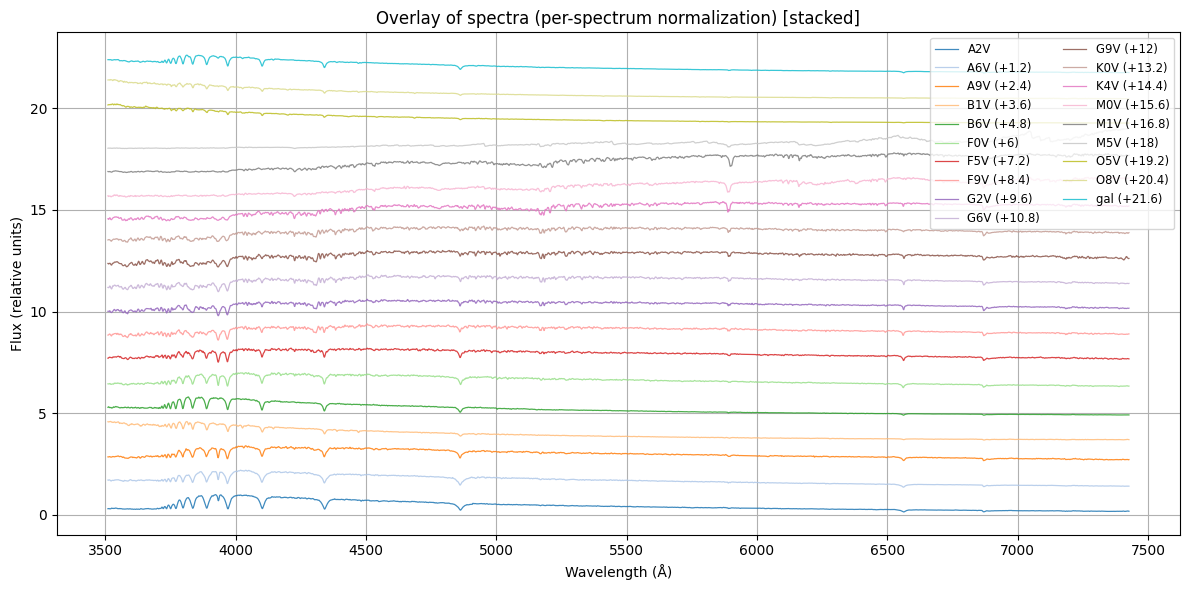

In [37]:
# Overlay with per-spectrum scaling (optionally stack vertically using offsets)
try:
    # Rebuild spectra dict in case it's not present in this scope
    spectra = {} # Dictionary to hold the spectra
    for var in list(globals().keys()): # Loop through global variables
        if var.endswith('_wl'): # Check for wavelength arrays
            base = var[:-3] # Get the base name by removing '_wl'
            wl = globals().get(var) # Get the wavelength array
            flux = globals().get(base + '_flux') # Get the corresponding flux array
            if wl is not None and flux is not None: # Ensure both arrays exist
                spectra[base] = {'wl': wl, 'flux': flux} # Store in the spectra dictionary

    if len(spectra) == 0: # Check if there are any spectra
        print('No spectra available to plot. Make sure the .npz file was loaded successfully.') # Notify the user
    else: # If there are spectra available
        # Per-spectrum scaling: set scalars here (keys are spectrum names without _wl/_flux)
        # Example: scales = {'A2V': 1.0, 'G9V': 0.5} to plot G9V at half the height of A2V (THIS ISN'T NECESSARY WHEN USING STACKING, BUT IF YOU WANT TO MANUALLY ADJUST HEIGHTS IT CAN BE USEFUL)
        scales = {
            'A2V': 1.0,
            'A6V': 1.0,
            'A9V': 1.0,
            'B1V': 1.0,
            'B6V': 1.0,
            'F0V': 1.0,
            'F5V': 1.0,
            'F9V': 1.0,
            'G2V': 1.0,
            'G6V': 1.0,
            'G9V': 1.0,
            'K0V': 1.0,
            'K4V': 1.0,
            'M0V': 1.0,
            'M1V': 1.0,
            'M5V': 1.0,
            'O5V': 1.0,
            'O8V': 1.0,
        }

        # Option: stack spectra vertically instead of plotting on the same baseline.
        # - Set `offset_mode = False` to keep the overlay behavior.
        # - If `offset_mode = True` you can provide per-spectrum additive offsets in `offsets`.
        # - When stacking we use per-spectrum normalization and then apply `scales` so multipliers
        #   increase the apparent height of a spectrum within its stack position (ladder behavior).
        offset_mode = True
        offsets = {name: 0.0 for name in spectra.keys()}  # user-editable per-spectrum offsets (additive, in the same units as plotted values)

        # Decide normalization mode for non-stacked plots:
        # - If all scales == 1.0 -> use per-spectrum normalization (no scaling)
        # - If any scale != 1.0 -> compute global max after scaling and normalize by that (preserve relative amplitudes)
        use_global_norm = any(v != 1.0 for v in scales.values())
        if offset_mode:
            # For stacked plotting we prefer per-spectrum normalization so each spectrum retains its own shape.
            use_global_norm = False

        # First compute (optionally scaled) maxima if global normalization is requested
        global_max = 0.0 # Variable to hold the global maximum value
        if use_global_norm: # Check if global normalization is requested
            for name, s in spectra.items(): # Loop through each spectrum
                raw_f = np.asarray(s['flux'], dtype=float) # Convert flux to numpy array
                f = raw_f * scales.get(name, 1.0) # Apply the scale factor
                if f.size == 0: # If the flux array is empty
                    continue # Skip to the next spectrum
                m = np.nanmax(np.abs(f)) # Compute the maximum absolute flux
                if np.isfinite(m) and m > global_max: # Check if the maximum is finite and greater than the current global maximum
                    global_max = m # Update the global maximum 

        import matplotlib.pyplot as plt 
        cmap = plt.get_cmap('tab20') # Color map for up to 20 distinct colors
        plt.figure(figsize=(12, 6)) # Create a new figure for plotting

        # Precompute plotted fluxes so we can apply automatic offsets when requested
        plotted = {} # Dictionary to hold precomputed plotted fluxes
        names_sorted = sorted(spectra.keys()) # Sort spectrum names for consistent plotting order
        for name in names_sorted: # Loop through each spectrum
            wl = np.asarray(spectra[name]['wl'], dtype=float) # Convert wavelength to numpy array
            raw_f = np.asarray(spectra[name]['flux'], dtype=float) # Convert flux to numpy array
            if raw_f.size == 0: # If the flux array is empty
                plotted[name] = (wl, raw_f, 0.0) # Store empty flux and zero peak
                continue # Skip to the next spectrum

            if use_global_norm:
                # global normalization: scale applied before normalization so relative amplitudes preserved
                f_scaled = raw_f * scales.get(name, 1.0) # Apply scale factor
                if global_max > 0: # Normalize by global max
                    f_plot = f_scaled / global_max # Normalize the scaled flux
                else: # If global max is zero, keep scaled flux as is
                    f_plot = f_scaled
            else: 
                # per-spectrum normalization
                maxval = np.nanmax(np.abs(raw_f))
                if maxval == 0 or np.isnan(maxval):
                    f_norm = raw_f
                else:
                    f_norm = raw_f / maxval
                # If stacking, multiply by scale after normalization so scale increases apparent height
                if offset_mode:
                    f_plot = f_norm * scales.get(name, 1.0)
                else:
                    # non-stacked per-spectrum normalization already accounts for scale via earlier branch
                    f_plot = f_norm

            # store peak for automatic spacing
            peak = 0.0 # Variable to hold the peak value
            try: # Try to compute the peak value
                peak = float(np.nanmax(np.abs(f_plot))) if f_plot.size else 0.0 # Compute the peak value
            except Exception: # Handle exceptions during peak computation
                peak = 0.0 # Default to zero if there's an error

            plotted[name] = (wl, f_plot, peak) # Store the precomputed values

        # If offset_mode is enabled, compute final offsets
        final_offsets = {name: float(offsets.get(name, 0.0)) for name in names_sorted} # Copy user-specified offsets
        if offset_mode: # If stacking is enabled
            # if user didn't provide any non-zero offsets, create automatic spacing
            if all(v == 0.0 for v in final_offsets.values()): # Check if all offsets are zero
                # Determine a spacing based on the median peak of the plotted spectra
                peaks = [p[2] for p in plotted.values() if p[2] is not None and p[2] > 0] # Collect peaks
                if len(peaks) == 0: # If no peaks are found
                    sep = 1.0 # Default separation
                else: # Compute separation based on median peak
                    sep = 1.2 * float(np.nanmedian(peaks)) # Compute separation
                    if sep == 0 or not np.isfinite(sep): # Validate separation
                        sep = 1.0 # Default separation
                for i, name in enumerate(names_sorted): # Assign offsets based on index
                    final_offsets[name] = i * sep # Set offset for stacking
            # otherwise keep user-specified offsets (already in final_offsets)

        # Plot each spectrum, applying offsets when requested
        ax = plt.gca() # Get current axes
        for i, name in enumerate(names_sorted): # Loop through each spectrum
            wl, f_plot, _ = plotted[name] # Get precomputed values
            if f_plot.size == 0: # If the flux array is empty
                continue  # Skip to the next spectrum

            offset = final_offsets.get(name, 0.0) if offset_mode else 0.0 # Get the offset
            label = name # Set the initial label
            # For stacked plots we applied scales to plotted values; for non-stacked we indicate scale in label
            if not offset_mode and scales.get(name, 1.0) != 1.0: # Check if scale is not 1.0
                label = f"{name} (×{scales.get(name)})" # Append scale to label
            if offset_mode and float(offset) != 0.0: # Check if offset is non-zero
                label = f"{label} (+{offset:g})" # Append offset to label

            ax.plot(wl, f_plot + offset, label=label, color=cmap(i % 20), lw=0.9, alpha=0.85) # Plot the spectrum with offset

        # Ensure axis limits include stacked offsets
        ax.relim() # Recompute the data limits
        ax.autoscale_view() # Autoscale the view to include all data
 
        plt.xlabel('Wavelength (Å)') # Label x-axis
        plt.ylabel('Flux (relative units)') # Label y-axis
        title_extra = ' (global normalization)' if use_global_norm else ' (per-spectrum normalization)' # Extra title info
        if offset_mode: # If stacking is enabled
            title_extra += ' [stacked]' # Append stacking info to title
        plt.title('Overlay of spectra' + title_extra) # Set the plot title
        plt.grid(True) # Enable grid
        try: # Try to set legend with multiple columns
            plt.legend(loc='upper right', fontsize='small', ncol=2) # Legend with 2 columns
        except Exception: # Fallback if ncol is not supported
            plt.legend(fontsize='small') # Simple legend
        plt.tight_layout() # Adjust layout
        plt.show() # Show the plot
except Exception as e: # Handle exceptions during plotting
    print('Error plotting overlay with per-spectrum scaling:', e) # Notify the user of the error

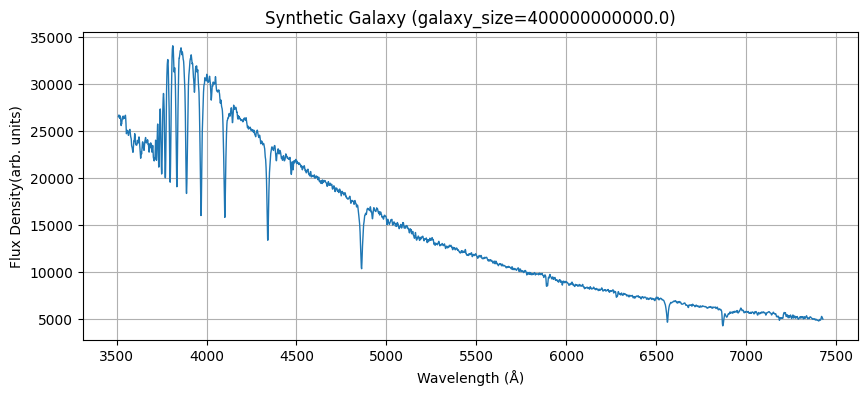

Output()

In [38]:
# Build class spectra and galaxy builder (per-class multipliers) with per-member weights
# Usage examples:
#   set_class_member_weights('O', {'O5V':0.25, 'O8V':0.75})
#   wl_o, flux_o = build_class_spectrum('O')
#   wl_gal, flux_gal = build_galaxy_spectrum({'O':50, 'G':1000})
try:
    # Ensure spectra dict exists (rebuild from globals if necessary)
    spectra = {} # Dictionary to hold the spectra
    for var in list(globals().keys()): # Loop through global variables
        if var.endswith('_wl'): # Check for wavelength arrays
            base = var[:-3] # Get the base name by removing '_wl'
            wl = globals().get(var) # Get the wavelength array
            flux = globals().get(base + '_flux') # Get the corresponding flux array
            if wl is not None and flux is not None: # Ensure both arrays exist
                spectra[base] = {'wl': wl, 'flux': flux} # Store in the spectra dictionary

    # Define class membership for available spectra (Theoretically we could include every single star type)
    classes = {
        'O': ['O5V', 'O8V'],
        'B': ['B1V', 'B6V'],
        'A': ['A2V', 'A6V', 'A9V'],
        'F': ['F0V', 'F5V', 'F9V'],
        'G': ['G6V', 'G9V', 'G2V'],
        'K': ['K0V', 'K4V'],
        'M': ['M0V', 'M1V', 'M5V'],
    }

    import numpy as np
    import matplotlib.pyplot as plt

    # Default per-member weights for classes (will be overridden with set_class_member_weights)
    # By default we distribute weight equally among listed members (This is just building a base for the code to work upon. dw)
    default_member_weights = {} # Dictionary to hold default member weights
    for c, members in classes.items(): # Loop through each class and its members
        if len(members) > 0: # Check if there are members in the class
            w = 1.0 / len(members) # Equal weight for each member
            default_member_weights[c] = {m: w for m in members} # Assign equal weights
        else: # If no members, assign empty dict
            default_member_weights[c] = {} # Empty weights

    def set_class_member_weights(class_name, weights_dict, normalize=True): # Set per-member weights for a class.
        """Set per-member weights for a class.

        - class_name: one-letter class (e.g. 'O').
        - weights_dict: mapping member_name -> weight (e.g. {'O5V':0.25, 'O8V':0.75}).
        - normalize: if True (default) scales weights so they sum to 1.0.
        """
        cname = class_name.upper() # Convert class name to uppercase
        if cname not in classes: # Check if class is valid
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}") # Raise error for unknown class
        # Keep only members that belong to class (If we were to add a class H102V it would be ignored)
        members = classes[cname] # Get members of the class
        filtered = {m: float(weights_dict.get(m, 0.0)) for m in members} # Filter weights for valid members
        if normalize: # Normalize weights if requested
            total = sum(filtered.values()) # Compute total weight
            if total > 0: # Check if total is greater than zero
                filtered = {m: v / total for m, v in filtered.items()} # Normalize weights
            else:
                # If total is zero, fallback to equal weights (Makes sure the code doesn't hang)
                filtered = {m: 1.0 / max(1, len(members)) for m in members} # Equal weights fallback
        default_member_weights[cname] = filtered # Update default member weights
        return default_member_weights[cname] # Return updated weights

    def get_class_members(class_name): # Return list of member names for a class.
        cname = class_name.upper() # Convert class name to uppercase
        if cname not in classes: # Check if class is valid
            raise ValueError(f"Unknown class '{class_name}'.") # Raise error for unknown class
        return classes[cname] # Return members of the class

    # Cache for class spectra (summed without per-class multiplier)
    class_spectra = {}  # Dictionary to hold cached class spectra

    def build_class_spectrum(class_name, member_weights=None, ref_wl=None, normalize_weights=True): # Build summed spectrum for a class.
        """Return (wl, flux) for the summed class spectrum (no multiplier applied).

        - class_name: one-letter class (e.g. 'O', 'G').
        - member_weights: optional dict mapping member name -> weight applied before summing.
                          If None, the stored `default_member_weights` for that class are used.
        - ref_wl: optional reference wavelength grid (1D array). If None, the first available member's wl is used.
        - normalize_weights: if True, weights are normalized to sum to 1.0 before use.
        """
        cname = class_name.upper() # Convert class name to uppercase 
        if cname not in classes:# Check if class is valid
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}") # Raise error for unknown class

        members = [m for m in classes[cname] if m in spectra] # Get available members in spectra
        if len(members) == 0: # If no members are available
            raise ValueError(f"No spectra available for class '{cname}'") # Raise error for no available spectra

        # Select weights: provided -> use; otherwise stored defaults
        weights = None # Variable to hold weights
        if member_weights is not None: # If member weights are provided
            weights = {m: float(member_weights.get(m, 0.0)) for m in members} # Use provided weights
        else: # Use default weights
            weights = {m: float(default_member_weights.get(cname, {}).get(m, 1.0)) for m in members} # Use default weights

        if normalize_weights: # Normalize weights if requested
            total = sum(weights.values()) #¤ Compute total weight
            if total > 0: # Check if total is greater than zero
                weights = {m: w / total for m, w in weights.items()} # Normalize weights
            else:
                # fallback to equal weights
                weights = {m: 1.0 / len(members) for m in members} # Equal weights fallback

        # Use provided ref_wl or the first member's wl
        if ref_wl is None: # use first member's wl
            ref_wl = np.asarray(spectra[members[0]]['wl'], dtype=float) # Convert to numpy array
        else: # use provided ref_wl
            ref_wl = np.asarray(ref_wl, dtype=float) # Convert to numpy array

        summed = np.zeros_like(ref_wl, dtype=float) # Initialize summed flux array
        for m in members:
            wl_m = np.asarray(spectra[m]['wl'], dtype=float) # Convert to numpy array
            flux_m = np.asarray(spectra[m]['flux'], dtype=float) # Convert to numpy array
            # Interpolate flux to reference grid; out-of-range values -> 0
            f_interp = np.interp(ref_wl, wl_m, flux_m, left=0.0, right=0.0) # Interpolation
            weight = weights.get(m, 0.0) # Get weight for member
            summed += f_interp * weight # Weighted sum

        # Cache by class (note: if different ref_wl used later, cache won't match)
        class_spectra[cname] = (ref_wl, summed) # Cache the class spectrum
        return ref_wl, summed # Return reference wavelength and summed flux

    def build_galaxy_spectrum(class_multipliers, ref_wl=None, member_weights=None, res=5000): # Build galaxy spectrum from class spectra and multipliers.
        """Sum class spectra using per-class multipliers.

        - class_multipliers: dict mapping class letter -> multiplier (e.g. {'O':50, 'G':1000})
        - ref_wl: optional reference grid. If None, a common grid spanning all member ranges is created.
        - member_weights: optional dict mapping class -> {member: weight} (overrides defaults)
        - res: number of points for auto-generated reference grid when ref_wl is None.
        Returns (ref_wl, galaxy_flux)
        """
        # Determine which classes are requested and available
        selected = {c: v for c, v in class_multipliers.items() if c.upper() in classes and v != 0} # Filter valid classes
        if len(selected) == 0:
            raise ValueError('No valid classes provided in class_multipliers') # Check for valid classes

        # If no ref grid provided, find overall min/max wl across selected members
        if ref_wl is None: # create common grid
            min_wl = np.inf # Initialize min_wl
            max_wl = -np.inf # Initialize max_wl
            for c in selected: # Iterate over selected classes
                for m in classes[c.upper()]: # Iterate over members of the class
                    if m in spectra: # Check if member spectrum is available
                        wl_m = np.asarray(spectra[m]['wl'], dtype=float) # Convert to numpy array
                        if wl_m.size: # If wavelength array is not empty
                            min_wl = min(min_wl, wl_m.min()) # Update min_wl
                            max_wl = max(max_wl, wl_m.max()) # Update max_wl
            if not np.isfinite(min_wl) or not np.isfinite(max_wl) or min_wl >= max_wl: # Check if valid range
                raise ValueError('Unable to determine wavelength range for selected classes') # Raise error if invalid
            # Create reference wavelength grid
            ref_wl = np.linspace(min_wl, max_wl, res) # Linear grid
        else: # use provided ref_wl
            ref_wl = np.asarray(ref_wl, dtype=float) # Convert to numpy array

        galaxy = np.zeros_like(ref_wl, dtype=float) # Initialize galaxy flux array
        for c, mult in selected.items(): # Iterate over selected classes
            weights_for_class = None # Initialize weights for class
            if member_weights and c in member_weights: # Check if member weights provided for class
                weights_for_class = member_weights[c] # Get weights for class
            try:
                _, class_flux = build_class_spectrum(c, member_weights=weights_for_class, ref_wl=ref_wl) # Build class spectrum
            except Exception as e:
                # skip missing class (Making sure the function doesn't fail completely if one class is missing)
                print(f"Skipping class {c}: {e}") # Notify about skipping class
                continue # Skip to next class
            galaxy += class_flux * mult # Add weighted class flux to galaxy

        return ref_wl, galaxy # Return reference wavelength and galaxy flux

    # Example: set specific star-class weights and build a small example using a user-specified galaxy_size
    try:
        # Set per-member weights of each class of stars
        set_class_member_weights('O', {'O5V': 0.34, 'O8V': 0.66}) # Set weights for O class
        set_class_member_weights('A', {'A2V': 0.15, 'A6V': 0.35, 'A9V': 0.50}) # Set weights for A class
        set_class_member_weights('B', {'B1V': 0.20, 'B6V': 0.80}) # Set weights for B class
        set_class_member_weights('F', {'F0V': 0.10, 'F5V': 0.25, 'F9V': 0.65}) # Set weights for F class
        set_class_member_weights('G', {'G2V': 0.15, 'G6V': 0.35, 'G9V': 0.50}) # Set weights for G class
        set_class_member_weights('K', {'K0V': 0.35, 'K4V': 0.65}) # Set weights for K class
        set_class_member_weights('M', {'M0V': 0.15, 'M1V': 0.35, 'M5V': 0.50}) # Set weights for M class

        # Specify galaxy_size (i.e what number of total stars do we want).
        galaxy_size = 400e9

        # Build a components dict that specifies how many of each type we want
        comps = {
            'O': 0.000003 * galaxy_size,
            'A': 0.06 * galaxy_size,
            'B': 0.013 * galaxy_size,
            'F': 0.03 * galaxy_size,
            'G': 0.76 * galaxy_size,
            'K': 0.121 * galaxy_size,
            'M': 0.765 * galaxy_size,
        } # We're using approximate real-world proportions of the milky way here

        # Build the galaxy spectrum using the currently stored member weights
        wl_gal, flux_gal = build_galaxy_spectrum(comps)

        # Save to globals for later use (idk this probably isn't necessary, let's see what the future assignments are)
        globals()['last_galaxy'] = (wl_gal, flux_gal)
        globals()['last_galaxy_components'] = comps
        globals()['galaxy_size'] = galaxy_size

        # Plot the result
        plt.figure(figsize=(10,4)) # Create a new figure
        plt.plot(wl_gal, flux_gal, lw=1.0) # Plot the galaxy spectrum
        plt.xlabel('Wavelength (Å)') # Label x-axis
        plt.ylabel('Flux Density(arb. units)') # Label y-axis
        plt.title(f'Synthetic Galaxy (galaxy_size={galaxy_size})') # Set the plot title
        plt.grid(True) # Enable grid
        plt.show() # Show the plot
    except Exception as e: # If anything were to go wrong this shit would fire
        print('Example galaxy weights/plot skipped:', e)

except Exception as e: # If anything were to go wrong this shit would fire
    print('Error setting up weighted class spectra:', e)

# --- Interactive class viewer + overlay (dropdown) ---
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # class_colors: define which colors we want each class to have
    class_colors = {
        'O': 'tab:blue',
        'B': 'tab:orange',
        'A': 'tab:green',
        'F': 'tab:red',
        'G': 'tab:purple',
        'K': 'tab:brown',
        'M': 'tab:gray',
    }
    # We'll make a function giving us the spectra of the synthetic galaxy as well as giving us the spectra for each
    # star class, as well as giving us the option to overlay the galaxy spectrum so we can compare them to see which 
    # class contributes what.
    def plot_class_and_optional_galaxy(class_name, overlay_galaxy=False):
        """Plot the summed class spectrum and optionally overlay the (simple normalized) galaxy spectrum.

        Both the class spectrum and the galaxy spectrum are normalized by dividing by their maximum absolute value
        so the plotted amplitudes are directly comparable (simple division as requested).
        """
        cname = class_name.upper() # Convert class name to uppercase
        try: # Get class spectrum
            wl_c, flux_c = build_class_spectrum(cname) # Build class spectrum
        except Exception as e: # Handle exceptions during class spectrum building
            print(f"Unable to build class spectrum for {cname}: {e}") # Notify about error
            return # Exit the function

        # Normalize class spectrum by its max (avoid division by zero)
        maxc = float(np.nanmax(np.abs(flux_c))) if (hasattr(flux_c, 'size') and flux_c.size) else 1.0 # Compute max value
        if maxc == 0 or not np.isfinite(maxc): # If the max is zero or not finite
            maxc = 1.0 # Default to 1.0 to avoid division by zero
        flux_c_norm = flux_c / maxc # Normalize the class flux

        fig, ax = plt.subplots(figsize=(9, 4)) # Create a new figure and axis
        color = class_colors.get(cname, 'k') # Get color for the class
        ax.plot(wl_c, flux_c_norm, color=color, lw=1.4, label=f"{cname} class (normalized)", zorder=2) # Plot class spectrum

        if overlay_galaxy: # Overlay galaxy if requested
            if 'last_galaxy' not in globals(): # Check if galaxy spectrum is available
                print('No galaxy spectrum available — run the galaxy builder example first.') # Notify about missing galaxy
            else: # If galaxy spectrum is available
                wl_gal, flux_gal = globals()['last_galaxy'] # Get the last galaxy spectrum
                # Simple normalization by max magnitude (AVOID DIVISION BY ZERO!)
                maxg = float(np.nanmax(np.abs(flux_gal))) if (hasattr(flux_gal, 'size') and flux_gal.size) else 1.0 # Compute max value
                if maxg == 0 or not np.isfinite(maxg): # If the max is zero or not finite
                    maxg = 1.0 # Default to 1.0 to avoid division by zero
                gal_norm = flux_gal / maxg # Normalize galaxy flux
                # Interpolate galaxy onto class wavelength grid and plot
                gal_interp = np.interp(wl_c, wl_gal, gal_norm, left=0.0, right=0.0) # Interpolate galaxy flux
                ax.plot(wl_c, gal_interp, color='0.4', lw=1.0, alpha=0.8, label='Galaxy (normalized)', zorder=1) # Plot galaxy spectrum

        ax.set_xlabel('Wavelength (Å)') # Label x-axis
        ax.set_ylabel('Normalized flux (max=1)') # Label y-axis
        ax.set_title(f"Class {cname} spectrum{(' + galaxy' if overlay_galaxy else '')}") # Set plot title
        ax.grid(True) # Enable grid
        ax.legend(fontsize='small') # Show legend
        plt.show() # Show the plot

    # Widgets: dropdown for class, checkbox to overlay galaxy
    if len(classes) == 0: # Check if there are any classes
        print('No classes available for interactive viewer') # Notify if no classes are available
    else: # If there are classes available
        class_dropdown = widgets.Dropdown(options=sorted(classes.keys()), description='Class:') # Create dropdown for class selection
        overlay_checkbox = widgets.Checkbox(value=False, description='Overlay galaxy') # Create checkbox for galaxy overlay
        out = widgets.Output() # Output widget for displaying the plot

        def _update(change=None, out=out): # Update plot on widget change.
            # bind `out` here to ensure this updater writes to the correct Output widget
            with out: # Use the output widget
                clear_output(wait=True) # Clear previous output
                plot_class_and_optional_galaxy(class_dropdown.value, overlay_checkbox.value) # Plot the selected class and optional galaxy

        class_dropdown.observe(_update, names='value') # Observe changes in class dropdown
        overlay_checkbox.observe(_update, names='value') # Observe changes in overlay checkbox

        display(widgets.HBox([class_dropdown, overlay_checkbox]), out) # Display the widgets and output

except Exception as e: # Handle exceptions related to ipywidgets
    print('To enable interactive class viewer install ipywidgets:', e) # Notify the user to install ipywidgets
    print('    pip install ipywidgets') # Suggest installation command

In the dropdown, if nothing appears you need to select the Class you want to compare and also tick the Overlay Galaxy button.

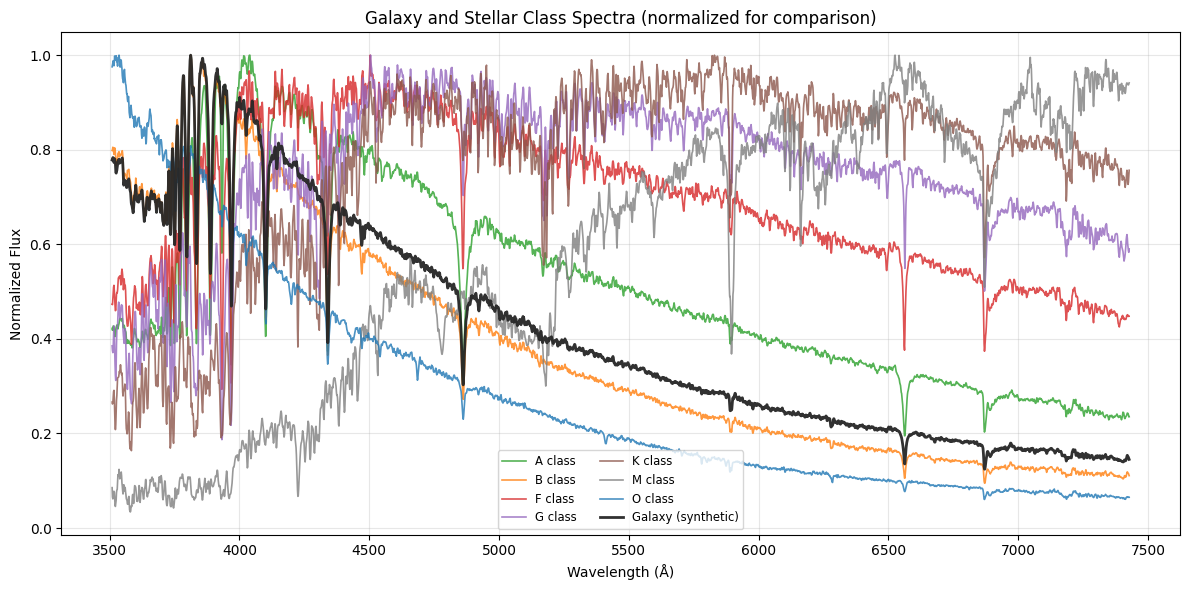

In [39]:
# Combined plot: galaxy spectrum + all class spectra (NORMALIZED for comparison)
# - Normalizes each spectrum by its maximum value so shapes and contributions are comparable
# - Allows visual comparison of which stellar classes contribute what features to the galaxy

import numpy as np
import matplotlib.pyplot as plt

# Check prerequisites
if 'spectra' not in globals() or len(spectra) == 0: # Ensure spectra dict exists
    raise RuntimeError('spectra dictionary not found. Run the earlier loading cell first.') # Notify if spectra dict is missing

# Obtain galaxy spectrum (use last_galaxy if present, otherwise try to build a simple example)
wl_gal = None # Wavelength array for galaxy
flux_gal = None # Flux array for galaxy
if 'last_galaxy' in globals(): # Use last_galaxy if available
    wl_gal, flux_gal = globals()['last_galaxy'] # Get the last galaxy spectrum
else:
    try:
        # Use the most recently constructed galaxy components when available so the plotted
        # galaxy represents the synthetic model the user created earlier in the notebook.
        if 'last_galaxy_components' in globals(): # Use last_galaxy_components if available
            comps_try = globals()['last_galaxy_components'] # Get the last galaxy components
        elif 'comps' in globals(): # Use comps if available
            comps_try = globals()['comps'] # Get the comps dictionary
        elif 'galaxy_size' in globals(): # Use galaxy_size if available
            # If only `galaxy_size` is present, reconstruct components using the same
            # fraction scheme used by the example builder so totals scale with galaxy_size.
            gs = float(globals()['galaxy_size']) # Get the galaxy size
            comps_try = { # Reconstruct components based on galaxy_size
                'O': 0.000003 * gs,
                'A': 0.06 * gs,
                'B': 0.013 * gs,
                'F': 0.03 * gs,
                'G': 0.76 * gs,
                'K': 0.121 * gs,
                'M': 0.765 * gs,
            }
        else:
            # No user-provided components: raise to make the situation explicit instead of
            # falling back to arbitrary small example numbers that don't reflect the synthetic galaxy.
            raise RuntimeError('No galaxy components found. Run the galaxy builder example first to create `last_galaxy_components` or set `comps`/`galaxy_size`.') # Notify about missing components
        wl_gal, flux_gal = build_galaxy_spectrum(comps_try) # Build galaxy spectrum
    except Exception as e: # Handle exceptions during galaxy spectrum building
        print('No galaxy spectrum available and build attempt failed:', e) # Notify about failure

# Classes list (fallback to unique first-letter groups if `classes` not available)
if 'classes' in globals() and isinstance(classes, dict) and len(classes) > 0: # Check if classes dict exists
    class_list = sorted(classes.keys()) # Use defined classes
else:
    # derive classes from spectra keys (first character)
    class_list = sorted({name[0] for name in spectra.keys()}) # Derive classes from spectra keys

# Prepare plot
fig, ax = plt.subplots(figsize=(12, 6)) # Create a new figure and axis
colors = plt.get_cmap('tab10') # Color map for up to 10 distinct colors

for i, cname in enumerate(class_list): # Loop through each class
    try: # Get class spectrum
        wl_c, flux_c = build_class_spectrum(cname) # Build class spectru
    except Exception as e:
        # skip missing/unbuildable classes
        print(f'Skipping class {cname}:', e)
        continue # Skip to next class

    # Normalize each class spectrum by its maximum value
    if not (hasattr(flux_c, 'size') and flux_c.size): # Check for empty flux array
        print(f'Class {cname} has empty flux array; skipping') # Notify about empty flux
        continue # Skip to next class
    
    flux_arr = np.asarray(flux_c, dtype=float) # Convert flux to numpy array
    maxval = np.nanmax(np.abs(flux_arr)) # Compute max value
    if maxval == 0 or not np.isfinite(maxval): # If the max is zero or not finite
        y_norm = flux_arr # Keep original flux to avoid division by zero
    else: # Normalize flux
        y_norm = flux_arr / maxval # Normalize the flux

    color = class_colors.get(cname, colors(i % 10)) if 'class_colors' in globals() else colors(i % 10) # Get color for the class
    ax.plot(wl_c, y_norm, label=f"{cname} class", color=color, lw=1.2, alpha=0.8)  # Plot class spectrum

# Plot galaxy if available — normalize it by its maximum value
if wl_gal is not None and flux_gal is not None: # Check if galaxy spectrum is available
    gal_arr = np.asarray(flux_gal, dtype=float) # Convert flux to numpy array
    maxval_gal = np.nanmax(np.abs(gal_arr)) # Compute max value
    if maxval_gal == 0 or not np.isfinite(maxval_gal): # If the max is zero or not finite
        gal_norm = gal_arr # Keep original flux to avoid division by zero
    else: # Normalize flux
        gal_norm = gal_arr / maxval_gal # Normalize the flux
    
    ax.plot(wl_gal, gal_norm, color='0.15', lw=2.0, alpha=0.95, label='Galaxy (synthetic)', zorder=10) # Plot galaxy spectrum

ax.set_xlabel('Wavelength (Å)') # Label x-axis
ax.set_ylabel('Normalized Flux') # Label y-axis
ax.set_title('Galaxy and Stellar Class Spectra (normalized for comparison)') # Set plot title
ax.grid(True, alpha=0.3) # Enable grid
ax.legend(fontsize='small', ncol=2, loc='best') # Show legend
plt.tight_layout() # Adjust layout
plt.show() # Show the plot


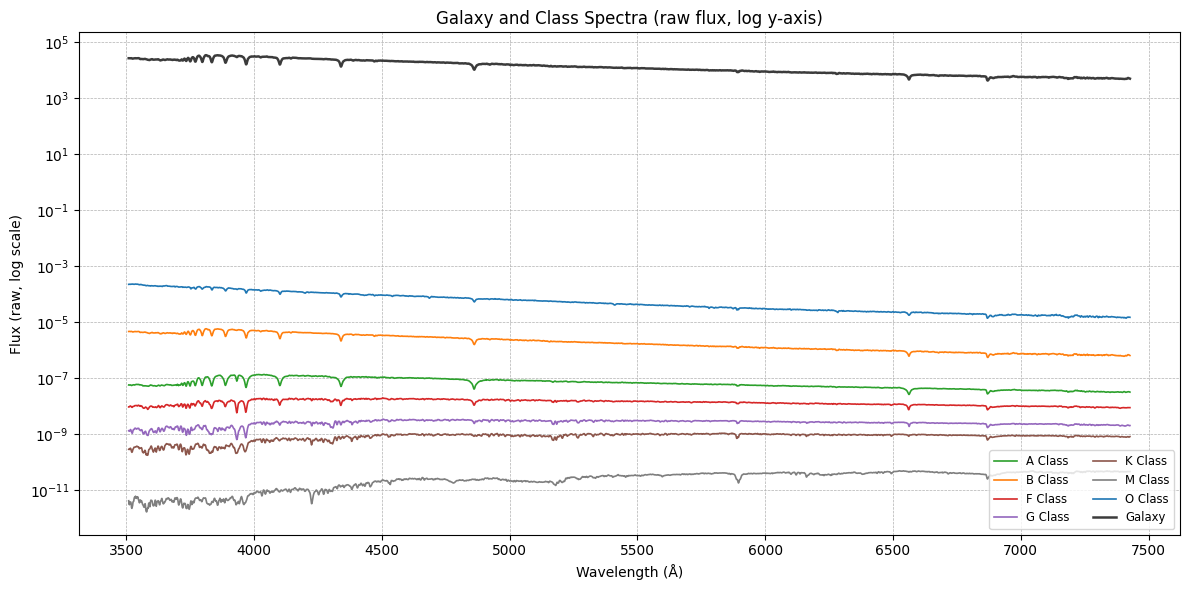

In [40]:
# Combined plot: galaxy spectrum + all class spectra on a log y-axis (RAW FLUX, no normalization)
# - Uses raw absolute flux for each class and for the galaxy (no normalization),
#   applies a small additive floor for log scale, and multiplicative offsets
#   so the traces remain visually separated on the log axis.
# - `spacing_exponent` controls how much vertical separation is applied per class:
#     factor = 10**(i * spacing_exponent)
#   Smaller `spacing_exponent` -> less separation. Set to 0 for no offsets.

import numpy as np
import matplotlib.pyplot as plt

# Check prerequisites
if 'spectra' not in globals() or len(spectra) == 0: # Ensure spectra dict exists
    raise RuntimeError('spectra dictionary not found. Run the earlier loading cell first.') # Notify if spectra dict is missing

# Obtain galaxy spectrum (use last_galaxy if present, otherwise try to build a simple example)
wl_gal = None # Wavelength array for galaxy
flux_gal = None # Flux array for galaxy
if 'last_galaxy' in globals(): # Use last_galaxy if available
    wl_gal, flux_gal = globals()['last_galaxy'] # Get the last galaxy spectrum
else:
    try:
        # Use the most recently constructed galaxy components when available so the plotted
        # galaxy represents the synthetic model the user created earlier in the notebook.
        if 'last_galaxy_components' in globals(): # Use last_galaxy_components if available
            comps_try = globals()['last_galaxy_components'] # Get the last galaxy components
        elif 'comps' in globals(): # Use comps if available
            comps_try = globals()['comps'] # Get the comps dictionary
        elif 'galaxy_size' in globals(): # Use galaxy_size if available
            # If only `galaxy_size` is present, reconstruct components using the same
            # fraction scheme used by the example builder so totals scale with galaxy_size.
            gs = float(globals()['galaxy_size']) # Get the galaxy size from globals
            comps_try = { # Reconstruct components based on galaxy_size
                'O': 0.000003 * gs,
                'A': 0.06 * gs,
                'B': 0.013 * gs,
                'F': 0.03 * gs,
                'G': 0.76 * gs,
                'K': 0.121 * gs,
                'M': 0.765 * gs,
            }
        else:
            # No user-provided components: raise to make the situation explicit instead of
            # falling back to arbitrary small example numbers that don't reflect the synthetic galaxy.
            raise RuntimeError('No galaxy components found. Run the galaxy builder example first to create `last_galaxy_components` or set `comps`/`galaxy_size`.')
        wl_gal, flux_gal = build_galaxy_spectrum(comps_try) # Build galaxy spectrum
    except Exception as e:
        print('No galaxy spectrum available and build attempt failed:', e) # Notify about failure

# Classes list (fallback to unique first-letter groups if `classes` not available)
if 'classes' in globals() and isinstance(classes, dict) and len(classes) > 0: # Check if classes dict exists
    class_list = sorted(classes.keys()) # use defined classes
else:
    # derive classes from spectra keys (first character)
    class_list = sorted({name[0] for name in spectra.keys()}) # Derive classes from spectra keys

# Prepare plot (plot raw flux for all traces with no multiplicative offsets)
fig, ax = plt.subplots(figsize=(12, 6)) # Create a new figure and axis
colors = plt.get_cmap('tab10') # Color map for up to 10 distinct colors
spacing_exponent = 0.0  # Set to 0.0 for no vertical offsets

tiny = 1e-30  # small floor to avoid zeros on log scale

for i, cname in enumerate(class_list): # Loop through each class
    try:
        wl_c, flux_c = build_class_spectrum(cname) # Build class spectrum
    except Exception as e:
        # skip missing/unbuildable classes
        print(f'Skipping class {cname}:', e) # Notify about skipping class
        continue # Skip to next class

    # Use raw absolute flux (no normalization, no multiplication)
    if not (hasattr(flux_c, 'size') and flux_c.size): # Check for empty flux array
        print(f'Class {cname} has empty flux array; skipping') # Notify about empty flux
        continue
    y_raw = np.abs(np.asarray(flux_c, dtype=float)) + tiny # Raw absolute flux with small floor

    # Do NOT apply any multiplicative offsets — plot raw flux directly
    y = y_raw

    color = class_colors.get(cname, colors(i % 10)) if 'class_colors' in globals() else colors(i % 10) # Get color for the class
    ax.plot(wl_c, y, label=f"{cname} Class", color=color, lw=1.2) # Plot class spectrum

# Plot galaxy if available — DO NOT normalize the galaxy (plot raw absolute flux)
if wl_gal is not None and flux_gal is not None: # Check if galaxy spectrum is available
    gal_y = np.abs(np.asarray(flux_gal, dtype=float)) + tiny # Raw absolute flux with small floor
    # Plot galaxy using its raw absolute flux on the same log axis
    ax.plot(wl_gal, gal_y, color='0.15', lw=1.8, alpha=0.9, label='Galaxy') # Plot galaxy spectrum

ax.set_yscale('log') # Set y-axis to logarithmic scale
ax.set_xlabel('Wavelength (Å)') # Label x-axis
ax.set_ylabel('Flux (raw, log scale)') # Label y-axis
ax.set_title('Galaxy and Class Spectra (raw flux, log y-axis)') # Set plot title
ax.grid(True, which='both', ls='--', lw=0.5) # Enable grid
ax.legend(fontsize='small', ncol=2) # Show legend
plt.tight_layout() # Adjust layout
plt.show() # Show the plot

gal1.fits wavelength array (length=1743):
[1235. 1240. 1245. ... 9935. 9940. 9945.]

gal2.fits wavelength array (length=1741):
[1235. 1240. 1245. ... 9925. 9930. 9935.]

Synthetic galaxy wavelength array (length=5000):
[3510.         3510.78359676 3511.56719352 ... 7425.63300648 7426.41660324
 7427.2002    ]


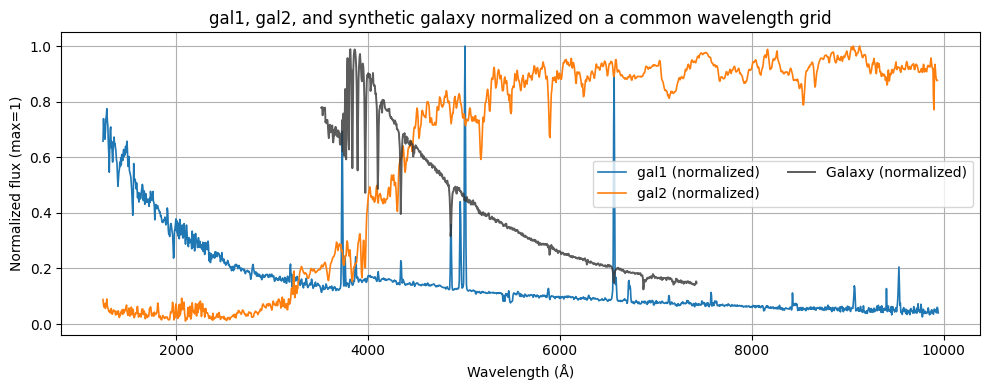

In [41]:
# Read gal1.fits and gal2.fits, extract wavelength arrays, and print them
# Also print the wavelength array from the synthetic galaxy spectrum created earlier.
# Additionally: plot gal1 and gal2 spectra using the extracted arrays, overlay the synthetic galaxy,
# and normalize all three traces for direct comparison on a single common wavelength grid

import os
import numpy as np
import matplotlib.pyplot as plt

# Try to use astropy for FITS I/O; if unavailable, guide user to install it
try:
    from astropy.io import fits # Import astropy fits module
except Exception as e: # Handle import errors
    print('Astropy not found. Install it to read FITS files:') # Notify user to install astropy
    print('    pip install astropy') # Suggest installation command
    raise


def get_wavelength_array(hdul):
    """Extract wavelength array from a FITS HDUList.

    Tries common patterns:
    - Primary/first image HDU with linear WCS via CRVAL1, CDELT1, CRPIX1, NAXIS1
    - Table HDU with a column named one of ['wavelength','WAVELENGTH','lambda','LAMBDA','wave','WAVE']
    Returns a 1D numpy array or raises ValueError if not found.
    """
    # 1) Look for table columns first
    for hdu in hdul: # Iterate through HDUs
        if hasattr(hdu, 'data') and hdu.data is not None: # Check if HDU has data
            if getattr(hdu, 'columns', None) is not None: # Check if HDU has columns
                colnames = [c.name for c in hdu.columns] # Get column names
                for name in ['wavelength', 'WAVELENGTH', 'lambda', 'LAMBDA', 'wave', 'WAVE']: # Common wavelength column names
                    if name in colnames: # Check if column name exists
                        data = hdu.data[name] # Get data from the column
                        arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                        if arr.size: # If array is not empty
                            return arr # Return wavelength array
                # If a single-column table, assume it's wavelength
                if len(colnames) == 1: # Check for single-column table
                    data = hdu.data[colnames[0]] # Get data from the single column
                    arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                    if arr.size: # If array is not empty
                        return arr # Return wavelength array
    
    # 2) Try image HDU with linear WCS keywords
    for hdu in hdul: # Iterate through HDUs
        hdr = getattr(hdu, 'header', None) # Get header from HDU
        data = getattr(hdu, 'data', None) # Get data from HDU
        if hdr is None:  # If header is None, skip
            continue # Skip to next HDU
        # Common linear dispersion keywords
        crval1 = hdr.get('CRVAL1') # Reference value for axis 1
        cdelt1 = hdr.get('CDELT1', hdr.get('CD1_1')) # Increment per pixel for axis 1
        crpix1 = hdr.get('CRPIX1') # Reference pixel for axis 1
        naxis1 = hdr.get('NAXIS1') or (data.shape[1] if (data is not None and data.ndim == 2) else (data.shape[0] if (data is not None and data.ndim == 1) else None)) # Number of pixels along axis 1
         # Check if all keywords are present
        if crval1 is not None and cdelt1 is not None and crpix1 is not None and naxis1 is not None:
            # FITS indexing: wavelength[i] = CRVAL1 + (i+1 - CRPIX1) * CDELT1
            i = np.arange(1, int(naxis1) + 1, dtype=float) # 1-based pixel indices
            wl = crval1 + (i - crpix1) * cdelt1 # Compute wavelength array
            return np.asarray(wl, dtype=float) # Return wavelength array
    
    raise ValueError('No wavelength information found in FITS file (no table column and no linear WCS keywords).') # Raise error if not found


def get_flux_array(hdul): # Same as above but for flux
    """Extract flux array from a FITS HDUList.

    Tries table columns named ['flux','FLUX','intensity','INTENSITY'].
    If an image HDU is present, returns the first row/column as 1D flux depending on shape.
    """
    # 1) Table columns
    for hdu in hdul: # Iterate through HDUs
        if hasattr(hdu, 'data') and hdu.data is not None: # Check if HDU has data
            if getattr(hdu, 'columns', None) is not None: # Check if HDU has columns
                colnames = [c.name for c in hdu.columns] # Get column names
                for name in ['flux', 'FLUX', 'intensity', 'INTENSITY']: # Common flux column names
                    if name in colnames: # Check if column name exists
                        data = hdu.data[name] # Get data from the column
                        arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                        if arr.size: # If array is not empty
                            return arr # Return flux array
                # If there are exactly two columns, assume second is flux 
                if len(colnames) == 2: # Check for two-column table
                    data = hdu.data[colnames[1]] # Get data from the second column
                    arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                    if arr.size: # If array is not empty
                        return arr # Return flux array
    # 2) Image HDU
    for hdu in hdul: # Iterate through HDUs
        data = getattr(hdu, 'data', None) # Get data from HDU
        if data is None: # If data is None, skip
            continue # Skip to next HDU
        arr = np.asarray(data, dtype=float) # Convert to numpy array
        if arr.ndim == 1: # 1D image
            return arr # Return flux array
        if arr.ndim == 2: # 2D image
            # Assume spectra in rows; take the first row
            return arr[0, :] # Return first row as flux array
    raise ValueError('No flux data found in FITS file (no table column and no image data).') # Raise error if not found


def read_wavelengths_and_flux(path): #Read wavelength and flux arrays from a FITS file at `path`.
    if not os.path.exists(path): 
        raise FileNotFoundError(f"File not found: {path}") # Check if file exists
    with fits.open(path) as hdul: # Open FITS file
        wl = get_wavelength_array(hdul) # Get wavelength array
        flux = get_flux_array(hdul) # Get flux array
        # Align sizes if needed
        n = min(wl.size, flux.size) # Determine minimum size
        return wl[:n], flux[:n] # Return aligned wavelength and flux arrays

# Assume files are in the same folder as the notebook
nb_dir = os.getcwd() # Get current working directory
file1 = os.path.join(nb_dir, 'gal1.fits') # Path to gal1.fits
file2 = os.path.join(nb_dir, 'gal2.fits') # Path to gal2.fits

# Read and print full arrays from gal1.fits and gal2.fits
wl_gal1 = None # Initialize galaxy 1 wavelength
wl_gal2 = None # Initialize galaxy 2 wavelength
flux_gal1 = None # Initialize galaxy 1 flux
flux_gal2 = None # Initialize galaxy 2 flux
try: # Read gal1.fits
    wl_gal1, flux_gal1 = read_wavelengths_and_flux(file1) # Read wavelengths and flux
    print(f"gal1.fits wavelength array (length={wl_gal1.size}):") # Print length
    print(wl_gal1) # Print wavelength array
except Exception as e:
    print('Failed to read wavelengths from gal1.fits:', e) # Handle exceptions

try: # Read gal2.fits
    wl_gal2, flux_gal2 = read_wavelengths_and_flux(file2) # Read wavelengths and flux
    print(f"\ngal2.fits wavelength array (length={wl_gal2.size}):") # Print length
    print(wl_gal2) # Print wavelength array
except Exception as e:
    print('Failed to read wavelengths from gal2.fits:', e) # Handle exceptions

# Print synthetic galaxy wavelengths from before and get flux for overlay
gal_wl = None # Initialize galaxy wavelength
gal_flux = None # Initialize galaxy flux
try:
    if 'last_galaxy' in globals(): # Use last_galaxy if available
        gal_wl, gal_flux = globals()['last_galaxy'] # Get the last galaxy spectrum
    else: # Build a simple example if last_galaxy not available
        # Attempt to reconstruct using previous components if available
        comps_try = None # Initialize components
        if 'last_galaxy_components' in globals(): # Use last_galaxy_components if available
            comps_try = globals()['last_galaxy_components'] # Get the last galaxy components
        elif 'comps' in globals(): # Use comps if available
            comps_try = globals()['comps'] # Get the comps dictionary
        elif 'galaxy_size' in globals(): # Use galaxy_size if available
            gs = float(globals()['galaxy_size']) # Get the galaxy size
            comps_try = { # Reconstruct components based on galaxy_size (gs)
                'O': 0.000003 * gs,
                'A': 0.06 * gs,
                'B': 0.013 * gs,
                'F': 0.03 * gs,
                'G': 0.76 * gs,
                'K': 0.121 * gs,
                'M': 0.765 * gs,
            }
        if comps_try is not None: # Build galaxy spectrum
            gal_wl, gal_flux = build_galaxy_spectrum(comps_try) # Build galaxy spectrum
    if gal_wl is not None: # If galaxy wavelengths are available
        gal_wl = np.asarray(gal_wl, dtype=float) # Convert to numpy array
        print(f"\nSynthetic galaxy wavelength array (length={gal_wl.size}):") # Print length
        print(gal_wl) # Print wavelength array
    else:
        print("\nSynthetic galaxy wavelengths unavailable. Run Cell 4 to build 'last_galaxy'.") # Notify if unavailable
except Exception as e:
    print('Failed to access synthetic galaxy wavelengths:', e) # Handle exceptions

# Plot normalized gal1, gal2, and synthetic galaxy, all resampled onto the same wavelength grid
try:
    fig, ax = plt.subplots(figsize=(10, 4)) # Create a new figure and axis

    # Normalize by max(|flux|) to avoid zeros and sign issues
    def norm_flux(y): # Normalize flux array by its maximum absolute value
        y = np.asarray(y, dtype=float) # Convert to numpy array
        m = float(np.nanmax(np.abs(y))) if y.size else 1.0 # Compute max value
        if m == 0 or not np.isfinite(m): # If the max is zero or not finite
            m = 1.0 # Default to 1.0 to avoid division by zero
        return y / m # Return normalized flux

    # Decide a single common wavelength grid: prefer gal1, else gal2, else galaxy's own grid
    common_wl = None # Initialize common wavelength array
    if wl_gal1 is not None: # If gal1 wavelengths are available
        common_wl = wl_gal1 # Use gal1 wavelengths
    elif wl_gal2 is not None: # If gal2 wavelengths are available
        common_wl = wl_gal2 # Use gal2 wavelengths
    elif gal_wl is not None: # If synthetic galaxy wavelengths are available
        common_wl = gal_wl # Use synthetic galaxy wavelengths

    if common_wl is None: # If no wavelength arrays are available
        print('No wavelength arrays available to define a common grid.') # Notify about missing wavelength arrays
    else:
        # Interpolate each available flux onto the common grid and plot (normalized)
        if wl_gal1 is not None and flux_gal1 is not None: # If gal1 data is available
            g1_interp = np.interp(common_wl, wl_gal1, norm_flux(flux_gal1), left=np.nan, right=np.nan) # Interpolate gal1 flux
            ax.plot(common_wl, g1_interp, lw=1.2, label='gal1 (normalized)') # Plot gal1 spectrum
        if wl_gal2 is not None and flux_gal2 is not None: # If gal2 data is available
            g2_interp = np.interp(common_wl, wl_gal2, norm_flux(flux_gal2), left=np.nan, right=np.nan) # Interpolate gal2 flux
            ax.plot(common_wl, g2_interp, lw=1.2, label='gal2 (normalized)') # Plot gal2 spectrum
        if gal_wl is not None and gal_flux is not None: # If synthetic galaxy data is available
            gal_interp = np.interp(common_wl, gal_wl, norm_flux(gal_flux), left=np.nan, right=np.nan) # Interpolate galaxy flux
            ax.plot(common_wl, gal_interp, color='0.2', lw=1.4, alpha=0.8, label='Galaxy (normalized)') # Plot galaxy spectrum

        ax.set_xlabel('Wavelength (Å)') # Label x-axis
        ax.set_ylabel('Normalized flux (max=1)') # Label y-axis
        ax.set_title('gal1, gal2, and synthetic galaxy normalized on a common wavelength grid') # Set plot title
        ax.grid(True) # Enable grid
        ax.legend(ncol=2) # Show legend
        plt.tight_layout() # Adjust layout
        plt.show() # Show the plot
except Exception as e: # Handle exceptions during plotting
    print('Error plotting normalized spectra on a common wavelength grid:', e) # Notify about error

In [42]:
# Check the actual flux values in gal1 and gal2 and print basic statistics
import numpy as np

if wl_gal1 is not None and flux_gal1 is not None:
    print("gal1 statistics:") # Print statistics for gal1
    print(f"  Wavelength range: {wl_gal1.min():.1f} - {wl_gal1.max():.1f} Å") # Print wavelength range
    print(f"  Flux range: {flux_gal1.min():.4e} - {flux_gal1.max():.4e}") # Print flux range
    print(f"  Flux mean: {np.mean(flux_gal1):.4e}") # Print flux mean
    print(f"  Flux median: {np.median(flux_gal1):.4e}") # Print flux median
    print()

if wl_gal2 is not None and flux_gal2 is not None:
    print("gal2 statistics:") # Print statistics for gal2
    print(f"  Wavelength range: {wl_gal2.min():.1f} - {wl_gal2.max():.1f} Å") # Print wavelength range
    print(f"  Flux range: {flux_gal2.min():.4e} - {flux_gal2.max():.4e}") # Print flux range
    print(f"  Flux mean: {np.mean(flux_gal2):.4e}") # Print flux mean
    print(f"  Flux median: {np.median(flux_gal2):.4e}") # Print flux median


gal1 statistics:
  Wavelength range: 1235.0 - 9945.0 Å
  Flux range: 8.1268e-15 - 3.1604e-13
  Flux mean: 4.8173e-14
  Flux median: 3.4349e-14

gal2 statistics:
  Wavelength range: 1235.0 - 9935.0 Å
  Flux range: 4.7403e-16 - 4.3586e-14
  Flux mean: 2.6819e-14
  Flux median: 3.6854e-14


In [43]:
# Interactive galaxy fitting tool with automatic optimization
# Choose gal1 or gal2, then fit star class composition AND galaxy size (no normalization)
# ONLY fits over the wavelength range covered by the synthetic galaxy spectra

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution # For optimization algorithms

# Try to use astropy for FITS I/O; if unavailable, guide user to install it
try:
    from astropy.io import fits
except Exception as e:
    print('Astropy not found. Install it to read FITS files:') # Notify user to install astropy
    print('    pip install astropy') # Suggest installation command
    raise

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    print('ipywidgets not found. Install it to enable interactive fitting:') # Notify user to install ipywidgets
    print('    pip install ipywidgets') # Suggest installation command
    raise


def get_wavelength_array(hdul):
    """Extract wavelength array from a FITS HDUList.

    Tries common patterns:
    - Primary/first image HDU with linear WCS via CRVAL1, CDELT1, CRPIX1, NAXIS1
    - Table HDU with a column named one of ['wavelength','WAVELENGTH','lambda','LAMBDA','wave','WAVE']
    Returns a 1D numpy array or raises ValueError if not found.
    """
    # 1) Look for table columns first
    for hdu in hdul: # Iterate through HDUs
        if hasattr(hdu, 'data') and hdu.data is not None: # Check if HDU has data
            if getattr(hdu, 'columns', None) is not None: # Check if HDU has columns
                colnames = [c.name for c in hdu.columns] # Get column names
                for name in ['wavelength', 'WAVELENGTH', 'lambda', 'LAMBDA', 'wave', 'WAVE']: # Common wavelength column names
                    if name in colnames: # Check if column name exists
                        data = hdu.data[name] # Get data from the column
                        arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                        if arr.size: # If array is not empty
                            return arr # Return wavelength array
                # If a single-column table, assume it's wavelength
                if len(colnames) == 1: # Check for single-column table
                    data = hdu.data[colnames[0]] # Get data from the single column
                    arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                    if arr.size: # If array is not empty
                        return arr # Return wavelength array
    
    # 2) Try image HDU with linear WCS keywords
    for hdu in hdul: # Iterate through HDUs
        hdr = getattr(hdu, 'header', None) # Get header from HDU
        data = getattr(hdu, 'data', None) # Get data from HDU
        if hdr is None: # If header is None, skip
            continue
        # Common linear dispersion keywords
        crval1 = hdr.get('CRVAL1') # Reference value for axis 1
        cdelt1 = hdr.get('CDELT1', hdr.get('CD1_1')) # Increment per pixel for axis 1
        crpix1 = hdr.get('CRPIX1') # Reference pixel for axis 1
        naxis1 = hdr.get('NAXIS1') or (data.shape[1] if (data is not None and data.ndim == 2) else (data.shape[0] if (data is not None and data.ndim == 1) else None)) # Number of pixels along axis 1
        if crval1 is not None and cdelt1 is not None and crpix1 is not None and naxis1 is not None: # Check if all keywords are present
            # FITS indexing: wavelength[i] = CRVAL1 + (i+1 - CRPIX1) * CDELT1
            i = np.arange(1, int(naxis1) + 1, dtype=float) # 1-based pixel indices 
            wl = crval1 + (i - crpix1) * cdelt1 # Compute wavelength array
            return np.asarray(wl, dtype=float) # Return wavelength array
    
    raise ValueError('No wavelength information found in FITS file (no table column and no linear WCS keywords).') # Raise error if not found


def get_flux_array(hdul): # The same as above but for flux
    """Extract flux array from a FITS HDUList.

    Tries table columns named ['flux','FLUX','intensity','INTENSITY'].
    If an image HDU is present, returns the first row/column as 1D flux depending on shape.
    """
    # 1) Table columns 
    for hdu in hdul: # Iterate through HDUs
        if hasattr(hdu, 'data') and hdu.data is not None: # Check if HDU has data
            if getattr(hdu, 'columns', None) is not None: # Check if HDU has columns
                colnames = [c.name for c in hdu.columns] # Get column names
                for name in ['flux', 'FLUX', 'intensity', 'INTENSITY']: # Common flux column names
                    if name in colnames: # Check if column name exists
                        data = hdu.data[name] # Get data from the column
                        arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                        if arr.size: # If array is not empty
                            return arr # Return flux array
                # If there are exactly two columns, assume second is flux
                if len(colnames) == 2: # Check for two-column table
                    data = hdu.data[colnames[1]] # Get data from the second column
                    arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                    if arr.size: # If array is not empty
                        return arr # Return flux array
    # 2) Image HDU
    for hdu in hdul: # Iterate through HDUs
        data = getattr(hdu, 'data', None) # Get data from HDU
        if data is None: # If data is None, skip
            continue # Skip to next HDU
        arr = np.asarray(data, dtype=float) # Convert to numpy array
        if arr.ndim == 1: # 1D image
            return arr # Return flux array
        if arr.ndim == 2: # 2D image
            # Assume spectra in rows; take the first row
            return arr[0, :] # Return first row as flux array
    raise ValueError('No flux data found in FITS file (no table column and no image data).') # Raise error if not found


def read_wavelengths_and_flux(path): # Read wavelength and flux arrays from a FITS file at `path`.
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}") # Check if file exists
    with fits.open(path) as hdul: # Open FITS file
        wl = get_wavelength_array(hdul) # Get wavelength array
        flux = get_flux_array(hdul) # Get flux array
        # Align sizes if needed
        n = min(wl.size, flux.size) # Determine minimum size
        return wl[:n], flux[:n] # Return aligned wavelength and flux arrays


# Assume files are in the same folder as the notebook
nb_dir = os.getcwd() # Get current working directory
file1 = os.path.join(nb_dir, 'gal1.fits') # Path to gal1.fits
file2 = os.path.join(nb_dir, 'gal2.fits') # Path to gal2.fits

# Read both galaxies
wl_gal1 = None # Wavelength array for gal1
flux_gal1 = None # Flux array for gal1
wl_gal2 = None # Wavelength array for gal2
flux_gal2 = None # Flux array for gal2

try:
    wl_gal1, flux_gal1 = read_wavelengths_and_flux(file1) # Read wavelengths and flux for gal1
    print(f"✓ Loaded gal1.fits (wavelength range: {wl_gal1.min():.1f}-{wl_gal1.max():.1f} Å)") # Print success message
except Exception as e:
    print(f'Failed to read gal1.fits: {e}') # Handle exceptions

try:
    wl_gal2, flux_gal2 = read_wavelengths_and_flux(file2) # Read wavelengths and flux for gal2
    print(f"✓ Loaded gal2.fits (wavelength range: {wl_gal2.min():.1f}-{wl_gal2.max():.1f} Å)") # Print success message
except Exception as e:
    print(f'Failed to read gal2.fits: {e}') # Handle exceptions

# Determine the wavelength range covered by synthetic galaxy (from stellar templates)
def get_synthetic_wavelength_range():
    """Determine min/max wavelength from available stellar spectra."""
    if 'spectra' not in globals() or len(globals()['spectra']) == 0: # Check if spectra dict exists
        # Fallback to reasonable defaults if spectra dict not available
        return 3000.0, 9000.0 # Return default wavelength range
    
    min_wl = np.inf # Initialize minimum wavelength
    max_wl = -np.inf # Initialize maximum wavelength
    for name, spec in globals()['spectra'].items(): # Loop through each spectrum
        wl = np.asarray(spec['wl'], dtype=float) # Get wavelength array
        if wl.size > 0: # Check if wavelength array is not empty
            min_wl = min(min_wl, wl.min()) # Update minimum wavelength
            max_wl = max(max_wl, wl.max()) # Update maximum wavelength
    
    if not np.isfinite(min_wl) or not np.isfinite(max_wl): # If no valid wavelengths found
        return 3000.0, 9000.0 # Return default wavelength range
    
    return min_wl, max_wl # Return determined wavelength range

synth_wl_min, synth_wl_max = get_synthetic_wavelength_range() # Get synthetic galaxy wavelength range
print(f"✓ Synthetic galaxy wavelength range: {synth_wl_min:.1f}-{synth_wl_max:.1f} Å") # Print synthetic wavelength range
print(f"  (Fitting will be restricted to this range)\n") # Notify about fitting range

# Interactive fitting interface
if wl_gal1 is None and wl_gal2 is None: # Check if neither galaxy is available
    print('Error: Could not load either gal1.fits or gal2.fits') # Print error message
else:
    # Optimization function: given fractions array + galaxy_size, compute RMS error (NO normalization)
    def compute_rms_error(params, wl_target, flux_target):
        """Compute RMS error for a given set of class fractions and galaxy size.
        params: [frac_O, frac_B, frac_A, frac_F, frac_G, frac_K, frac_M, galaxy_size_log]
        
        NOTE: wl_target and flux_target should already be trimmed to synthetic wavelength range
        """
        # Extract fractions and galaxy size
        fractions_unnormalized = params[:-1] # class fractions
        galaxy_size_log = params[-1]  # log10 of galaxy size
        galaxy_size = 10**galaxy_size_log # Convert log size to linear size
        
        # Normalize fractions to sum to 1.0
        total_frac = sum(fractions_unnormalized) # Sum of unnormalized fractions
        if total_frac <= 0:
            return 1e20 # Return large error if all fractions are zero or negative
        fractions = np.array(fractions_unnormalized) / total_frac # Normalize fractions
        
        # Build synthetic galaxy
        components = {class_names[i]: fractions[i] * galaxy_size for i in range(len(class_names))} # Scale fractions by galaxy size
        
        try:
            wl_synth, flux_synth = build_galaxy_spectrum(components, ref_wl=wl_target) # Build synthetic galaxy spectrum
        except Exception as e:
            return 1e20 # Return large error if building fails
        
        # Compute error WITHOUT normalization (direct comparison of raw fluxes)
        diff = flux_target - flux_synth # Difference between target and synthetic flux
        rms_error = np.sqrt(np.nanmean(diff**2)) # Compute RMS error
        return rms_error # Return RMS error
    
    class_names = ['O', 'B', 'A', 'F', 'G', 'K', 'M'] # List of stellar class names
    
    # Create widgets
    galaxy_dropdown = widgets.Dropdown( # Select galaxy to fit
        options=['gal1', 'gal2'], # Options for galaxy selection
        description='Select galaxy to fit:', # Description for dropdown
        style={'description_width': '150px'} # Style for description width
    )
    
    # Sliders for class composition
    sliders = {
        'O': widgets.FloatSlider(value=0.0001, min=0.0, max=1.0, step=0.00001, description='O fraction:', readout_format='.5e'), # Slider for O class fraction
        'B': widgets.FloatSlider(value=0.01, min=0.0, max=1.0, step=0.00001, description='B fraction:', readout_format='.5e'), # Slider for B class fraction
        'A': widgets.FloatSlider(value=0.06, min=0.0, max=1.0, step=0.00001, description='A fraction:', readout_format='.5e'), # Slider for A class fraction
        'F': widgets.FloatSlider(value=0.03, min=0.0, max=1.0, step=0.00001, description='F fraction:', readout_format='.5e'), # Slider for F class fraction
        'G': widgets.FloatSlider(value=0.76, min=0.0, max=1.0, step=0.00001, description='G fraction:', readout_format='.5e'), # Slider for G class fraction
        'K': widgets.FloatSlider(value=0.121, min=0.0, max=1.0, step=0.00001, description='K fraction:', readout_format='.5e'), # Slider for K class fraction
        'M': widgets.FloatSlider(value=0.765, min=0.0, max=1.0, step=0.00001, description='M fraction:', readout_format='.5e'), # Slider for M class fraction
    }
    
    # Galaxy size slider (log scale) - adjusted to match observed flux amplitudes (10^-16 to 10^3)
    galaxy_size_slider = widgets.FloatLogSlider(
        value=1e-14, # Initial galaxy size
        base=10, # Log base 10
        min=-20,  # 10^-20 # Minimum galaxy size
        max=10,    # 10^10  # Maximum galaxy size
        step=0.01, # Step size
        description='Galaxy size:', # Description for slider
        readout_format='.5e' # Readout format
    )
    
    # Button for automatic optimization
    optimize_button = widgets.Button(description='🔍 Auto-Optimize', button_style='info', tooltip='Find best fit automatically') # Button for automatic optimization
    optimize_status = widgets.HTML(value='<i>Ready</i>') # Status display for optimization
    
    output_widget = widgets.Output() # Output widget for displaying results
    
    def update_fit(change=None):
        """Update the synthetic galaxy fit when galaxy selection or sliders change."""
        with output_widget:
            clear_output(wait=True) # Clear previous output
            
            # Get selected galaxy
            selected = galaxy_dropdown.value # Get selected galaxy from dropdown
            if selected == 'gal1' and wl_gal1 is None: # Check if gal1 is available
                print('gal1 is not available') # Print error message
                return
            if selected == 'gal2' and wl_gal2 is None: # Check if gal2 is available
                print('gal2 is not available') # Print error message
                return
            
            wl_full = wl_gal1 if selected == 'gal1' else wl_gal2 # Get full wavelength array
            flux_full = flux_gal1 if selected == 'gal1' else flux_gal2 # Get full flux array
            
            # Trim to synthetic wavelength range
            mask = (wl_full >= synth_wl_min) & (wl_full <= synth_wl_max) # Create mask for synthetic wavelength range
            wl_target = wl_full[mask] # Trimmed wavelength array
            flux_target = flux_full[mask] # Trimmed flux array
            
            if wl_target.size == 0: # Check if there are any data points in the synthetic wavelength range
                print(f'Error: No data in synthetic wavelength range ({synth_wl_min:.1f}-{synth_wl_max:.1f} Å)') # Print error message
                return # Exit function
            
            # Get class fractions from sliders
            fractions = {name: slider.value for name, slider in sliders.items()} # Get fractions from sliders
            
            # Normalize fractions to sum to 1.0
            total_frac = sum(fractions.values()) # Sum of fractions
            if total_frac > 0: # Check if total fraction is greater than zero
                fractions = {c: f / total_frac for c, f in fractions.items()} # Normalize fractions
            else:
                print('Error: All sliders are zero. Please adjust at least one slider.') # Print error message
                return
            
            # Get galaxy size from slider
            galaxy_size = galaxy_size_slider.value # Get galaxy size from slider
            
            # Build synthetic galaxy with these fractions and galaxy size
            components = {c: fractions[c] * galaxy_size for c in fractions} # Scale fractions by galaxy size
             
            try: # Build synthetic galaxy spectrum
                wl_synth, flux_synth = build_galaxy_spectrum(components, ref_wl=wl_target) # Build synthetic galaxy spectrum
            except Exception as e: 
                print(f'Error building synthetic galaxy: {e}') # Print error message
                return
            
            # Calculate RMS error (NO normalization)
            diff = flux_target - flux_synth # Difference between target and synthetic flux
            rms_error = np.sqrt(np.nanmean(diff**2)) # Compute RMS error
            
            # Calculate Pearson correlation coefficient and convert to percentage
            # Remove NaN values for correlation calculation
            valid_mask = ~(np.isnan(flux_target) | np.isnan(flux_synth)) # Mask for valid (non-NaN) values
            if np.sum(valid_mask) > 1: # Ensure there are enough valid points
                correlation_coef = np.corrcoef(flux_target[valid_mask], flux_synth[valid_mask])[0, 1] # Compute correlation coefficient
                correlation_percent = correlation_coef * 100 # Convert to percentage
            else:
                correlation_percent = np.nan # Not enough valid points for correlation 
            
            # Plot comparison (RAW flux, no normalization) - ONLY synthetic range
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7)) # Create subplots
            
            # Top panel: overlay of target and synthetic (raw flux)
            ax1.plot(wl_target, flux_target, label=f'{selected} (target)', lw=1.2, color='navy', alpha=0.8) # Plot target spectrum
            ax1.plot(wl_synth, flux_synth, label='Synthetic fit', lw=1.2, color='red', alpha=0.7, linestyle='--') # Plot synthetic spectrum
            ax1.set_ylabel('Flux (raw units)') # Label y-axis
            ax1.set_title(f'Fitting {selected} (RMS: {rms_error:.2e}, Goodness of fit: {correlation_percent:.2f}%, Galaxy size: {galaxy_size:.2e})') # Set plot title
            ax1.set_xlim(synth_wl_min, synth_wl_max) # Set x-axis limits
            ax1.grid(True) # Enable grid
            ax1.legend(fontsize='small', loc='upper right') # Show legend
            
            # Bottom panel: residuals (raw flux)
            residuals = flux_target - flux_synth # Compute residuals
            ax2.plot(wl_target, residuals, label='Residual (target - synthetic)', lw=1.0, color='green') # Plot residuals
            ax2.axhline(y=0, color='k', linestyle=':', lw=0.8) # Horizontal line at y=0
            ax2.fill_between(wl_target, 0, residuals, alpha=0.3, color='green') # Fill area under residuals
            ax2.set_xlabel('Wavelength (Å)') # Label x-axis
            ax2.set_ylabel('Flux difference (raw units)') # Label y-axis
            ax2.set_xlim(synth_wl_min, synth_wl_max) # Set x-axis limits
            ax2.grid(True) # Enable grid
            ax2.legend(fontsize='small', loc='upper right') # Show legend
            
            plt.tight_layout() # Adjust layout
            plt.show() # Show the plot
            
            # Print class fractions, galaxy size, and correlation
            print(f'\nFitting wavelength range: {synth_wl_min:.1f}-{synth_wl_max:.1f} Å ({wl_target.size} points)') # Print fitting wavelength range
            print('\nClass fractions in synthetic galaxy:') # Print class fractions
            for c, f in fractions.items(): # Loop through each class  
                print(f"  {c}: {f*100:.2f}%") # Print each class fraction
            print(f'\nGalaxy size: {galaxy_size:.2e}') # Print galaxy size
            print(f'RMS: {rms_error:.4e}') # Print RMS error
            print(f'Goodness of fit: {correlation_percent:.2f}%') # Print goodness of fit percentage
    
    def on_optimize_clicked(b):
        """Run automatic optimization to find best fit (including galaxy size)."""
        with output_widget: # Use output widget for display
            clear_output(wait=True) # Clear previous output
            
            # Get selected galaxy
            selected = galaxy_dropdown.value # Get selected galaxy from dropdown
            if selected == 'gal1' and wl_gal1 is None: # Check if gal1 is available
                print('gal1 is not available') # Print error message
                return
            if selected == 'gal2' and wl_gal2 is None: # Check if gal2 is available
                print('gal2 is not available') # Print error message
                return
            
            wl_full = wl_gal1 if selected == 'gal1' else wl_gal2 # Get full wavelength array
            flux_full = flux_gal1 if selected == 'gal1' else flux_gal2 # Get full flux array
            
            # Trim to synthetic wavelength range
            mask = (wl_full >= synth_wl_min) & (wl_full <= synth_wl_max) # Create mask for synthetic wavelength range
            wl_target = wl_full[mask] # Trimmed wavelength array
            flux_target = flux_full[mask] # Trimmed flux array
            
            if wl_target.size == 0: # Check if there are any data points in the synthetic wavelength range
                print(f'Error: No data in synthetic wavelength range ({synth_wl_min:.1f}-{synth_wl_max:.1f} Å)') # Print error message
                return # Exit function
            
            print(f'🔄 Optimizing fit for {selected} (including galaxy size)...') # This message appears when optimization is underway
            print(f'Fitting over {synth_wl_min:.1f}-{synth_wl_max:.1f} Å ({wl_target.size} points)') # Print fitting wavelength range
            print('This may take a moment...\n') # Notify user about optimization time
            
            # Bounds: [O, B, A, F, G, K, M, log10(galaxy_size)]
            # Galaxy size range: 10^-20 to 10^10 (to cover wide flux amplitudes)
            bounds = [
                (0.0, 1.0),   # O
                (0.0, 1.0),   # B
                (0.0, 1.0),   # A
                (0.0, 1.0),   # F
                (0.0, 1.0),   # G
                (0.0, 1.0),   # K
                (0.0, 1.0),   # M
                (-20.0, 10.0)  # log10(galaxy_size)
            ]
            
            def objective(x):
                return compute_rms_error(x, wl_target, flux_target) # Objective function for optimization
            
            try:
                result = differential_evolution(objective, bounds, maxiter=500, seed=42, workers=1, updating='deferred') # Run differential evolution optimization
                best_params = result.x # Best-fit parameters
                best_error = result.fun # Best RMS error
            except Exception as e: # Handle optimization exceptions
                print(f'Optimization failed: {e}') # Print error message
                return
            
            # Extract and normalize fractions
            best_fractions_unnormalized = best_params[:-1] # Best-fit unnormalized fractions
            best_galaxy_size_log = best_params[-1] # Best-fit log10 of galaxy size
            best_galaxy_size = 10**best_galaxy_size_log # Convert log size to linear size
            
            total_frac = sum(best_fractions_unnormalized) # Sum of best-fit unnormalized fractions
            if total_frac > 0: # Check if total fraction is greater than zero
                best_fractions = best_fractions_unnormalized / total_frac # Normalize best-fit fractions
            else:
                best_fractions = best_fractions_unnormalized # Return unnormalized if total is zero (should not happen)
            
            print(f'✓ Optimization complete! Best RMS error: {best_error:.4e}\n') # Print optimization completion message
            print('Updated fractions:') # Print updated fractions
            for i, class_name in enumerate(class_names): # Loop through each class
                new_val = best_fractions[i] # Get best-fit fraction for class
                sliders[class_name].value = new_val # Update slider value
                print(f"  {class_name}: {new_val*100:.2f}%") # Print each class fraction
            
            # Update galaxy size slider
            galaxy_size_slider.value = best_galaxy_size # Update galaxy size slider
            print(f'\nBest galaxy size: {best_galaxy_size:.2e}') # Print best galaxy size
            
            # Trigger update to display the optimized fit
            print('\nUpdating plot...\n') # Notify user about plot update
            update_fit() # Update the fit display
    
    optimize_button.on_click(on_optimize_clicked) # Attach click event to optimization button
    
    # Attach observers to update plot when selections change
    galaxy_dropdown.observe(update_fit, names='value') # Update fit when galaxy selection changes
    for slider in sliders.values():
        slider.observe(update_fit, names='value') # Update fit when any class fraction slider changes
    galaxy_size_slider.observe(update_fit, names='value') # Update fit when galaxy size slider changes
    
    # Display interface
    slider_vbox = widgets.VBox(list(sliders.values()) + [galaxy_size_slider]) # VBox for sliders
    optimize_box = widgets.HBox([optimize_button, optimize_status]) # Box for optimization button and status
    controls = widgets.VBox([galaxy_dropdown, optimize_box, widgets.HTML('<b>Adjust star class fractions and galaxy size:</b>'), slider_vbox]) # VBox for all controls
    display(widgets.HBox([controls])) # Display controls
    display(output_widget) # Display output widget
    
    # Initial plot
    update_fit()


✓ Loaded gal1.fits (wavelength range: 1235.0-9945.0 Å)
✓ Loaded gal2.fits (wavelength range: 1235.0-9935.0 Å)
✓ Synthetic galaxy wavelength range: 3510.0-7427.2 Å
  (Fitting will be restricted to this range)



Output()

# For the following cell: Please ensure that the SSP and SSP2 folders are within the folder the Notebook is in. This is crucial...

In [44]:
# Read SSP (Simple Stellar Population) FITS files and compare with synthetic galaxy
import os
import glob
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Path to SSP folder (relative to notebook location)
ssp_folder = os.path.join(os.path.dirname(os.path.abspath('Exercise 2 Release.ipynb')), 'SSP') # Set SSP folder path
if not os.path.exists(ssp_folder):
    # Try alternative path (current working directory)
    ssp_folder = os.path.join(os.getcwd(), 'SSP') # Alternative SSP folder path
    if not os.path.exists(ssp_folder):
        raise FileNotFoundError(f'SSP folder not found. Expected at: {ssp_folder}') # Raise error if folder not found

print(f'Reading SSP spectra from: {ssp_folder}') # Print SSP folder path

# Find all .fits files matching s*.fits pattern
fits_files = glob.glob(os.path.join(ssp_folder, 's*.fits')) # Get list of FITS files
print(f'Found {len(fits_files)} FITS files') # Print number of found FITS files

# Dictionary to store SSP spectra: {age_in_years: {'wl': array, 'flux': array, 'label': str}}
ssp_spectra = {} # Initialize dictionary for SSP spectra

def parse_age_from_filename(filename):
    """Extract age in years from filename like s1gy.fits, s100My.fits, s500ky.fits
    Returns (age_in_years, label_string)
    """
    basename = os.path.basename(filename) # Get base filename
    # Match pattern like s1gy, s100My, s500ky
    match = re.match(r's(\d+(?:\.\d+|p\d+)?)(gy|My|ky)\.fits', basename) # Regex to extract age and unit
    if not match: # If no match found
        return None, None # Return None if parsing fails
    
    number_str = match.group(1).replace('p', '.')  # Handle s5p2My -> 5.2
    number = float(number_str) # Convert to float
    unit = match.group(2) # Get unit (gy, My, ky)
    
    # Convert to years
    if unit == 'gy':  # Giga years (billion)
        age_years = number * 1e9 # Convert to years
        label = f'{number} Gy' # Create label
    elif unit == 'My':  # Million years
        age_years = number * 1e6 # Convert to years
        label = f'{number} My' # Create label
    elif unit == 'ky':  # Kilo years (thousand)
        age_years = number * 1e3 # Convert to years
        label = f'{number} ky' # Create label
    else:
        return None, None # Return None if unit is unrecognized
    
    return age_years, label # Return age in years and label

# Read each FITS file
for fits_file in fits_files: # Loop through each FITS file
    try:
        age_years, label = parse_age_from_filename(fits_file) # Parse age from filename
        if age_years is None: # If parsing failed
            print(f'Warning: Could not parse age from {os.path.basename(fits_file)}') # Warn if parsing fails
            continue
        
        # Open FITS file
        with fits.open(fits_file) as hdul: # Open FITS file
            # FITS files typically have data in the primary HDU or first extension
            # Try to find the spectrum data
            data = None # Initialize data variable
            header = None # Initialize header variable
            
            if len(hdul) > 0 and hdul[0].data is not None: # Check primary HDU
                data = hdul[0].data # Get data from primary HDU
                header = hdul[0].header # Get header from primary HDU
            elif len(hdul) > 1: # Check first extension HDU
                data = hdul[1].data # Get data from first extension HDU
                header = hdul[1].header # Get header from first extension HDU
            
            if data is None: # If no data found
                print(f'Warning: No data found in {os.path.basename(fits_file)}') # Warn if no data found
                continue # Skip to next file
            
            # Extract wavelength and flux
            # Common FITS spectrum formats:
            # - 1D array: flux only, wavelength from header (CRVAL1, CDELT1)
            # - 2D array: might be [wavelength, flux] or similar
            
            if data.ndim == 1:
                # 1D flux array, construct wavelength from header
                flux = data # Get flux array
                npoints = len(flux) # Number of data points
                
                # FITS WCS keywords
                crval1 = header.get('CRVAL1', 0)  # Starting wavelength
                cdelt1 = header.get('CDELT1', 1)  # Wavelength step
                crpix1 = header.get('CRPIX1', 1)  # Reference pixel
                
                # Construct wavelength array
                wl = crval1 + (np.arange(npoints) - (crpix1 - 1)) * cdelt1
                
            elif data.ndim == 2:
                # 2D array - try different interpretations
                if data.shape[0] == 2: # If first dimension is 2
                    # [wl, flux]
                    wl = data[0] # Get wavelength array
                    flux = data[1] # Get flux array
                elif data.shape[1] == 2: # If second dimension is 2
                    # [[wl, flux], [wl, flux], ...]
                    wl = data[:, 0] # Get wavelength array
                    flux = data[:, 1] # Get flux array
                else:
                    # Take first row/column as wavelength
                    wl = data[0] # Get wavelength array
                    flux = data[1] if data.shape[0] > 1 else data[:, 1] # Get flux array
            else:
                print(f'Warning: Unexpected data shape {data.shape} in {os.path.basename(fits_file)}') # Warn about unexpected shape
                continue # Skip to next file
            
            # Store in dictionary
            ssp_spectra[age_years] = { # Store spectrum in dictionary
                'wl': np.asarray(wl, dtype=float), # Wavelength array
                'flux': np.asarray(flux, dtype=float), # Flux array
                'label': label # Label string
            }
            
            print(f'  Loaded {label}: {len(wl)} points, wl range {wl.min():.1f}-{wl.max():.1f} Å') # Print loaded spectrum info
            
    except Exception as e:
        print(f'Error reading {os.path.basename(fits_file)}: {e}') # Handle exceptions during file reading

print(f'\nSuccessfully loaded {len(ssp_spectra)} SSP spectra') # Print number of successfully loaded spectra

# Store in globals for later use
globals()['ssp_spectra'] = ssp_spectra # Store SSP spectra in globals

Reading SSP spectra from: c:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Galaxy-Girls\SSP
Found 10 FITS files
  Loaded 100.0 My: 9300 points, wl range 700.0-9999.0 Å
  Loaded 10.0 My: 9300 points, wl range 700.0-9999.0 Å
  Loaded 13.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 16.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 1.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 20.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 400.0 My: 9300 points, wl range 700.0-9999.0 Å
  Loaded 4.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 500.0 ky: 9300 points, wl range 700.0-9999.0 Å
  Loaded 5.2 My: 9300 points, wl range 700.0-9999.0 Å

Successfully loaded 10 SSP spectra


- Compare the overall shape and features to estimate the age of our synthetic galaxy
- Our synthetic galaxy is shown in RED with dashed line
- SSP spectra are color-coded by age (purple=young, yellow=old)

Visual comparison guide:


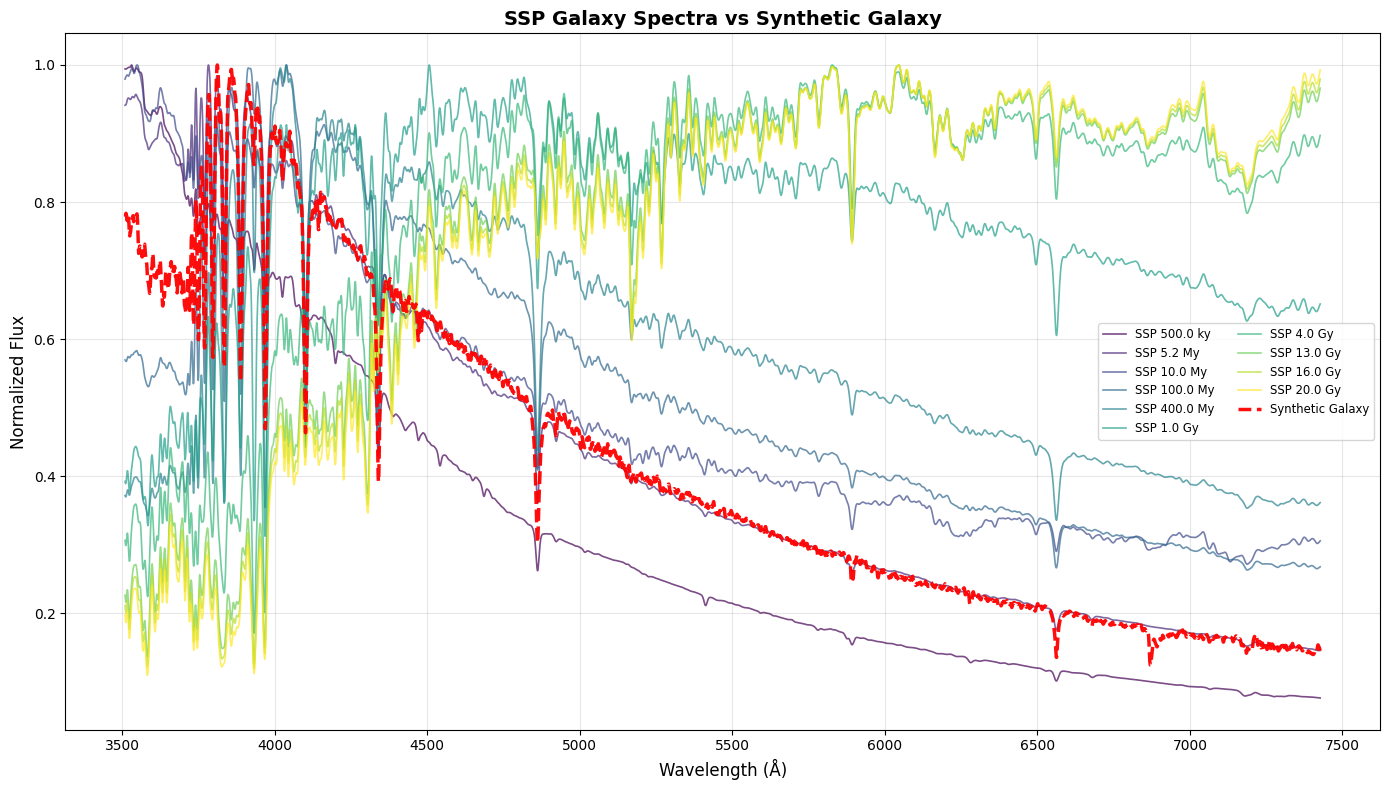

In [45]:
# Plot SSP spectra compared with synthetic galaxy spectrum
import numpy as np
import matplotlib.pyplot as plt

if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0: # Check if SSP spectra are loaded
    raise RuntimeError('SSP spectra not loaded. Run the previous cell first.') # Raise error if not loaded

# Get synthetic galaxy spectrum
if 'last_galaxy' in globals(): # Check if last_galaxy exists
    wl_synth, flux_synth = globals()['last_galaxy'] # Get synthetic galaxy spectrum
else:
    raise RuntimeError('No synthetic galaxy spectrum found. Run the galaxy builder cell first.') # Raise error if not found

# Determine wavelength range of synthetic galaxy
wl_min_synth = np.min(wl_synth) # Minimum wavelength of synthetic galaxy
wl_max_synth = np.max(wl_synth) # Maximum wavelength of synthetic galaxy

# Sort SSP spectra by age
ages_sorted = sorted(ssp_spectra.keys()) # Sorted list of ages

# Create plot
fig, ax = plt.subplots(figsize=(14, 8)) # Create figure and axis

# Color map for SSP spectra (from young to old)
cmap = plt.get_cmap('viridis') # Use viridis colormap
colors_ssp = [cmap(i / max(1, len(ages_sorted) - 1)) for i in range(len(ages_sorted))] # Generate colors for each SSP

# Plot each SSP spectrum (normalized, restricted to synthetic galaxy wavelength range)
for i, age in enumerate(ages_sorted): # Loop through each SSP age
    spec = ssp_spectra[age] # Get spectrum data
    wl = spec['wl'] # Wavelength array
    flux = spec['flux'] # Flux array
    label = spec['label'] # Label string
    
    # Restrict to synthetic galaxy wavelength range
    mask = (wl >= wl_min_synth) & (wl <= wl_max_synth) # Create mask for overlap range
    wl_restricted = wl[mask] # Restricted wavelength array
    flux_restricted = flux[mask] # Restricted flux array
    
    if len(wl_restricted) == 0:
        continue  # Skip if no overlap
    
    # Normalize by maximum value within restricted range
    flux_arr = np.asarray(flux_restricted, dtype=float) # Convert flux to numpy array
    maxval = np.nanmax(np.abs(flux_arr)) # Maximum absolute flux value
    if maxval > 0 and np.isfinite(maxval): # Check for valid max value
        flux_norm = flux_arr / maxval # Normalize flux
    else:  # If maxval is zero or invalid
        flux_norm = flux_arr # # Use original flux
    
    ax.plot(wl_restricted, flux_norm, color=colors_ssp[i], lw=1.2, alpha=0.7, label=f'SSP {label}') # Plot SSP spectrum

# Plot synthetic galaxy (normalized, with thicker line for visibility)
flux_synth_arr = np.asarray(flux_synth, dtype=float) # Convert synthetic flux to numpy array
maxval_synth = np.nanmax(np.abs(flux_synth_arr)) # Maximum absolute flux value for synthetic galaxy
if maxval_synth > 0 and np.isfinite(maxval_synth): # Check for valid max value
    flux_synth_norm = flux_synth_arr / maxval_synth # Normalize synthetic flux
else:
    flux_synth_norm = flux_synth_arr # Use original synthetic flux

ax.plot(wl_synth, flux_synth_norm, color='red', lw=2.5, alpha=0.95,  # Plot synthetic galaxy
        label='Synthetic Galaxy', zorder=100, linestyle='--') # Dashed line for visibility


ax.set_xlabel('Wavelength (Å)', fontsize=12) # Label x-axis
print('- Compare the overall shape and features to estimate the age of our synthetic galaxy')

ax.set_ylabel('Normalized Flux', fontsize=12) # Label y-axis
print('- Our synthetic galaxy is shown in RED with dashed line')

ax.set_title('SSP Galaxy Spectra vs Synthetic Galaxy', fontsize=14, fontweight='bold') # Set plot title
print('- SSP spectra are color-coded by age (purple=young, yellow=old)')
ax.grid(True, alpha=0.3) # Enable grid with transparency
print('\nVisual comparison guide:') # Guidance for visual comparison

ax.legend(fontsize='small', ncol=2, loc='best') # Show legend

plt.tight_layout() # Adjust layout
plt.show() # Show the plot

In [46]:
# Interactive comparison: select SSP age to compare directly with synthetic galaxy
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import numpy as np
    import matplotlib.pyplot as plt

    if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0: # Check if SSP spectra are loaded
        print('SSP spectra not loaded. Run the SSP loading cell first.') # Notify if not loaded
    elif 'last_galaxy' not in globals(): # Check if synthetic galaxy exists
        print('No synthetic galaxy spectrum found. Run the galaxy builder cell first.') # Notify if not found
    else:
        # Get synthetic galaxy
        wl_synth, flux_synth = globals()['last_galaxy'] # Get synthetic galaxy spectrum
        
        # Determine wavelength range of synthetic galaxy
        wl_min_synth = np.min(wl_synth) # Minimum wavelength of synthetic galaxy
        wl_max_synth = np.max(wl_synth) # Maximum wavelength of synthetic galaxy
        
        # Prepare dropdown options (sorted by age)
        ages_sorted = sorted(ssp_spectra.keys()) # Sorted list of ages
        options = [(ssp_spectra[age]['label'], age) for age in ages_sorted] # Create options for dropdown
        
        dropdown = widgets.Dropdown(  # Create dropdown for SSP age selection
            options=options, # Options for dropdown
            description='SSP Age:', # Description for dropdown
            value=ages_sorted[len(ages_sorted)//2] if ages_sorted else None  # Start with middle age
        )
        out = widgets.Output() # Output widget for displaying plots
        
        def on_change(change, out=out): # Callback for dropdown change
            if change.get('name') == 'value': # Check if value changed1
                with out: # Use output widget
                    clear_output(wait=True) # Clear previous output
                    age = change.get('new') # Get selected age
                    spec = ssp_spectra[age] # Get selected SSP spectrum
                    wl_ssp = spec['wl'] # Wavelength array of SSP
                    flux_ssp = spec['flux'] # Flux array of SSP
                    label_ssp = spec['label'] # Label of SSP
                    
                    # Restrict SSP to synthetic galaxy wavelength range
                    mask = (wl_ssp >= wl_min_synth) & (wl_ssp <= wl_max_synth) # Create mask for overlap range
                    wl_ssp_restricted = wl_ssp[mask] # Restricted wavelength array
                    flux_ssp_restricted = flux_ssp[mask] # Restricted flux array
                    
                    # Normalize both spectra
                    flux_ssp_arr = np.asarray(flux_ssp_restricted, dtype=float) # Convert SSP flux to numpy array
                    max_ssp = np.nanmax(np.abs(flux_ssp_arr)) # Maximum absolute flux value for SSP
                    if max_ssp > 0 and np.isfinite(max_ssp): # Check for valid max value
                        flux_ssp_norm = flux_ssp_arr / max_ssp # Normalize SSP flux
                    else:
                        flux_ssp_norm = flux_ssp_arr # Use original SSP flux
                    
                    flux_synth_arr = np.asarray(flux_synth, dtype=float) # Convert synthetic flux to numpy array
                    max_synth = np.nanmax(np.abs(flux_synth_arr)) # Maximum absolute flux value for synthetic galaxy
                    if max_synth > 0 and np.isfinite(max_synth): # Check for valid max value
                        flux_synth_norm = flux_synth_arr / max_synth # Normalize synthetic flux
                    else:
                        flux_synth_norm = flux_synth_arr # Use original synthetic flux
                    
                    # Plot comparison
                    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8)) # Create subplots
                    
                    # Top panel: overlay
                    ax1.plot(wl_ssp_restricted, flux_ssp_norm, color='blue', lw=1.5, alpha=0.8, label=f'SSP {label_ssp}') # Plot SSP spectrum
                    ax1.plot(wl_synth, flux_synth_norm, color='red', lw=1.5, alpha=0.8,  # Plot synthetic galaxy
                            label='Synthetic Galaxy', linestyle='--') # Dashed line for visibility
                    ax1.set_xlabel('Wavelength (Å)') # Label x-axis
                    ax1.set_ylabel('Normalized Flux') # Label y-axis
                    ax1.set_title(f'Comparison: SSP {label_ssp} vs Synthetic Galaxy') # Set plot title
                    ax1.grid(True, alpha=0.3) # Enable grid with transparency
                    ax1.legend(fontsize='medium') # Show legend
                    
                    # Bottom panel: residual (interpolate SSP to synthetic wavelength grid)
                    flux_ssp_interp = np.interp(wl_synth, wl_ssp_restricted, flux_ssp_norm, left=np.nan, right=np.nan) # Interpolate SSP flux
                    residual = flux_synth_norm - flux_ssp_interp # Compute residual
                     
                    ax2.plot(wl_synth, residual, color='purple', lw=1.0) # Plot residual
                    ax2.axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.5) # Horizontal line at y=0
                    ax2.set_xlabel('Wavelength (Å)') # Label x-axis
                    ax2.set_ylabel('Residual (Synth - SSP)') # Label y-axis
                    ax2.set_title('Residual Spectrum') # Set plot title
                    ax2.grid(True, alpha=0.3) # Enable grid with transparency
                    
                    # Calculate RMS of residual (excluding NaNs)
                    valid = ~np.isnan(residual) # Valid (non-NaN) mask
                    if np.any(valid): # Check if there are valid points
                        rms = np.sqrt(np.nanmean(residual[valid]**2)) # Compute RMS of residual
                        # Calculate correlation coefficient
                        corr_matrix = np.corrcoef(flux_synth_norm[valid], flux_ssp_interp[valid]) # Correlation matrix
                        correlation = corr_matrix[0, 1] # Correlation coefficient
                        corr_percent = correlation * 100 # Convert to percentage
                        
                        ax2.text(0.02, 0.98, f'RMS = {rms:.4f}\nCorrelation = {corr_percent:.2f}%',  # Display RMS and correlation
                                transform=ax2.transAxes, fontsize=10, # Font size
                                verticalalignment='top', # Align text to top
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)) # Text box style
                    
                    plt.tight_layout() # Adjust layout
                    plt.show() # Show the plot
        
        dropdown.observe(on_change, names='value') # Attach observer to dropdown
        display(dropdown, out) # Display dropdown and output widget
        
        # Trigger initial plot
        on_change({'name': 'value', 'new': dropdown.value}) # Initial plot display

except Exception as e:
    print('Interactive comparison requires ipywidgets:', e) # Notify if ipywidgets is not available
    print('Install with: pip install ipywidgets') # Installation instruction

Dropdown(description='SSP Age:', index=5, options=(('500.0 ky', 500000.0), ('5.2 My', 5200000.0), ('10.0 My', …

Output()

In [47]:
# Read observed galaxy spectra (gal1.fits and gal2.fits)
import os
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Path to workspace folder
workspace_folder = os.getcwd() # Assuming current working directory

# Dictionary to store observed galaxies
observed_galaxies = {} # Initialize dictionary for observed galaxies

for gal_name in ['gal1', 'gal2']: # Loop through each galaxy
    gal_file = os.path.join(workspace_folder, f'{gal_name}.fits') # Construct file path
    
    if not os.path.exists(gal_file): # Check if file exists
        print(f'Warning: {gal_name}.fits not found at {gal_file}') # Warn if file not found
        continue # Skip to next galaxy
    
    try:
        with fits.open(gal_file) as hdul: # Open FITS file
            # Try to find the spectrum data
            data = None # Initialize data variable
            header = None # Initialize header variable
            
            if len(hdul) > 0 and hdul[0].data is not None: # Check primary HDU
                data = hdul[0].data # Get data from primary HDU
                header = hdul[0].header # Get header from primary HDU
            elif len(hdul) > 1: # Check first extension HDU
                data = hdul[1].data # Get data from first extension HDU
                header = hdul[1].header # Get header from first extension HDU
            
            if data is None: # If no data found
                print(f'Warning: No data found in {gal_name}.fits') # Warn if no data found
                continue # Skip to next file
            
            # Extract wavelength and flux
            if data.ndim == 1:
                # 1D flux array, construct wavelength from header
                flux = data # Get flux array
                npoints = len(flux) # Number of data points
                
                # FITS WCS keywords
                crval1 = header.get('CRVAL1', 0) # Starting wavelength
                cdelt1 = header.get('CDELT1', 1) # Wavelength step
                crpix1 = header.get('CRPIX1', 1) # Reference pixel
                
                # Construct wavelength array
                wl = crval1 + (np.arange(npoints) - (crpix1 - 1)) * cdelt1 # Wavelength array
                
            elif data.ndim == 2: # If 2D array
                # 2D array
                if data.shape[0] == 2: # If first dimension is 2
                    wl = data[0] # Get wavelength array
                    flux = data[1] # Get flux array
                elif data.shape[1] == 2:# If second dimension is 2
                    wl = data[:, 0] # Get wavelength array
                    flux = data[:, 1] # Get flux array
                else:
                    wl = data[0] # Get wavelength array
                    flux = data[1] if data.shape[0] > 1 else data[:, 1] # Get flux array
            else:
                print(f'Warning: Unexpected data shape {data.shape} in {gal_name}.fits') # Warn about unexpected shape
                continue # Skip to next file
            
            # Store in dictionary
            observed_galaxies[gal_name] = { # Store observed galaxy spectrum
                'wl': np.asarray(wl, dtype=float), # Wavelength array
                'flux': np.asarray(flux, dtype=float) # Flux array
            }
            
            print(f'Loaded {gal_name}: {len(wl)} points, wl range {wl.min():.1f}-{wl.max():.1f} Å') # Print loaded galaxy info
            
    except Exception as e: # Handle exceptions during file reading
        print(f'Error reading {gal_name}.fits: {e}') # Print error message

print(f'\nSuccessfully loaded {len(observed_galaxies)} observed galaxy spectra') # Print number of successfully loaded galaxies

# Store in globals for later use
globals()['observed_galaxies'] = observed_galaxies # Store observed galaxies in globals

Loaded gal1: 1743 points, wl range 1235.0-9945.0 Å
Loaded gal2: 1741 points, wl range 1235.0-9935.0 Å

Successfully loaded 2 observed galaxy spectra


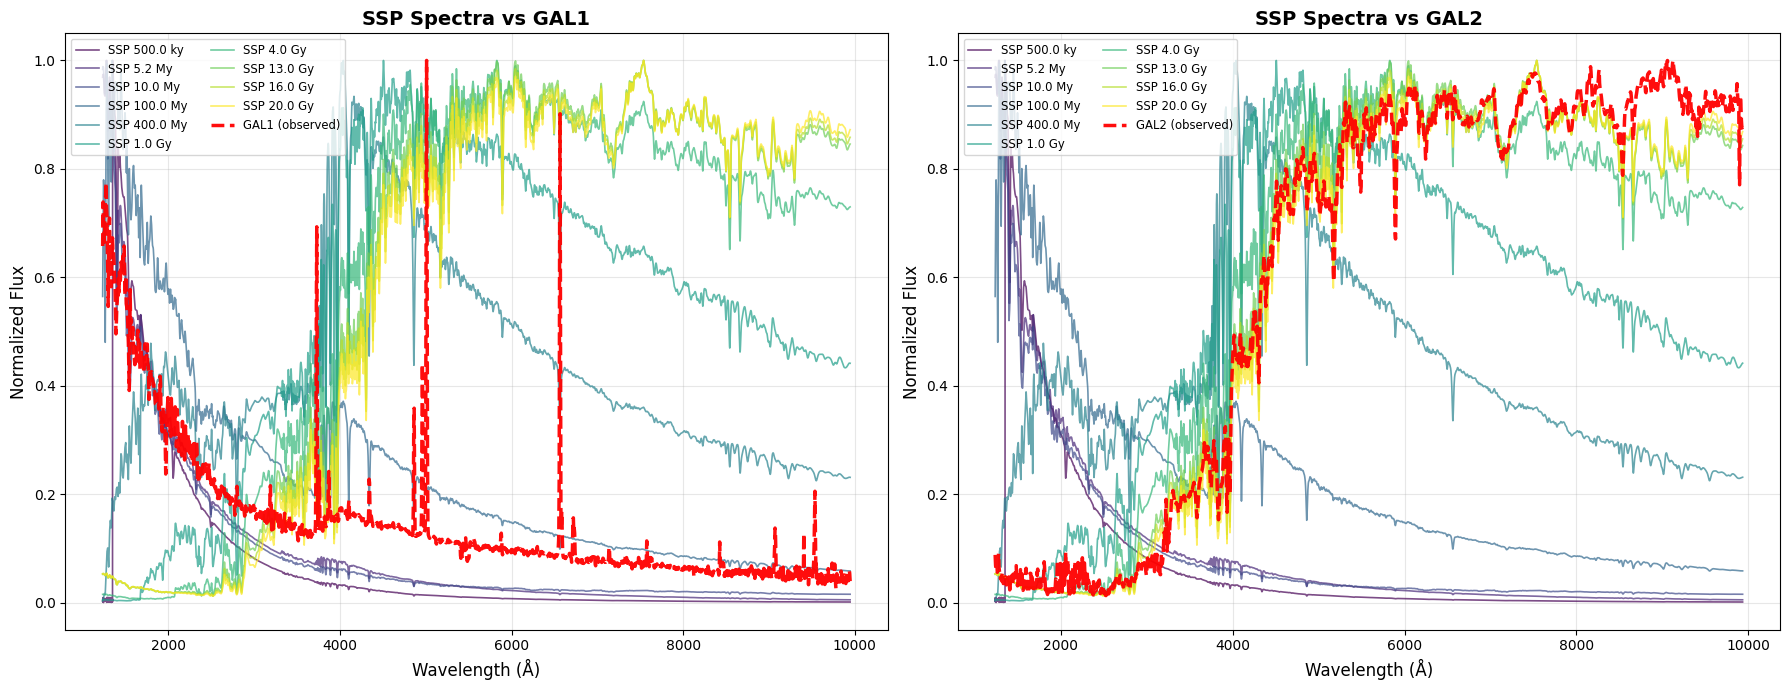


Visual comparison guide:
- SSP spectra are color-coded by age (purple=young, yellow=old)
- Observed galaxies are shown in RED with dashed lines
- Compare the overall shape and features to estimate the age of each galaxy


In [48]:
# Plot SSP spectra compared with gal1 and gal2
import numpy as np
import matplotlib.pyplot as plt

if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0: #   Check if SSP spectra are loaded
    raise RuntimeError('SSP spectra not loaded. Run the SSP loading cell first.') # Raise error if not loaded

if 'observed_galaxies' not in globals() or len(observed_galaxies) == 0: # Check if observed galaxies are loaded
    raise RuntimeError('Observed galaxies not loaded. Run the previous cell first.') # Raise error if not loaded

# Sort SSP spectra by age
ages_sorted = sorted(ssp_spectra.keys()) # Sorted list of ages

# Color map for SSP spectra (from young to old)
cmap = plt.get_cmap('viridis') # Use viridis colormap
colors_ssp = [cmap(i / max(1, len(ages_sorted) - 1)) for i in range(len(ages_sorted))] # Generate colors for each SSP

# Create subplots for gal1 and gal2
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Create figure and axes

for idx, (gal_name, gal_data) in enumerate(sorted(observed_galaxies.items())): # Loop through each observed galaxy
    ax = axes[idx] # Select corresponding axis
    wl_obs = gal_data['wl'] # Wavelength of observed galaxy
    flux_obs = gal_data['flux'] # Flux of observed galaxy
    
    # Determine wavelength range of observed galaxy
    wl_min_obs = np.min(wl_obs) # Minimum wavelength of observed galaxy
    wl_max_obs = np.max(wl_obs) # Maximum wavelength of observed galaxy
    
    # Plot each SSP spectrum (normalized, restricted to observed galaxy wavelength range)
    for i, age in enumerate(ages_sorted): # Loop through each SSP age
        spec = ssp_spectra[age] # Get spectrum data
        wl = spec['wl'] # Wavelength array
        flux = spec['flux'] # Flux array
        label = spec['label'] # Label string
        
        # Restrict to observed galaxy wavelength range
        mask = (wl >= wl_min_obs) & (wl <= wl_max_obs) # Create mask for overlap range
        wl_restricted = wl[mask] # Restricted wavelength array
        flux_restricted = flux[mask] # Restricted flux array
        
        if len(wl_restricted) == 0: # Skip if no overlap
            continue # Skip if no overlap
        
        # Normalize by maximum value within restricted range
        flux_arr = np.asarray(flux_restricted, dtype=float) # Convert flux to numpy array
        maxval = np.nanmax(np.abs(flux_arr)) # Maximum absolute flux value
        if maxval > 0 and np.isfinite(maxval): # Check for valid max value
            flux_norm = flux_arr / maxval # Normalize flux
        else: # If maxval is zero or invalid
            flux_norm = flux_arr # Use original flux
        
        ax.plot(wl_restricted, flux_norm, color=colors_ssp[i], lw=1.2, alpha=0.7, label=f'SSP {label}') # Plot SSP spectrum
    
    # Plot observed galaxy (normalized, with thicker line for visibility)
    flux_obs_arr = np.asarray(flux_obs, dtype=float) # Convert observed flux to numpy array
    maxval_obs = np.nanmax(np.abs(flux_obs_arr)) # Maximum absolute flux value for observed galaxy
    if maxval_obs > 0 and np.isfinite(maxval_obs): # Check for valid max value
        flux_obs_norm = flux_obs_arr / maxval_obs # Normalize observed flux
    else:
        flux_obs_norm = flux_obs_arr # Use original observed flux
    
    ax.plot(wl_obs, flux_obs_norm, color='red', lw=2.5, alpha=0.95,  # Plot observed galaxy
            label=f'{gal_name.upper()} (observed)', zorder=100, linestyle='--') # Dashed line for visibility
    
    ax.set_xlabel('Wavelength (Å)', fontsize=12) # Label x-axis
    ax.set_ylabel('Normalized Flux', fontsize=12) # Label y-axis
    ax.set_title(f'SSP Spectra vs {gal_name.upper()}', fontsize=14, fontweight='bold') # Set plot title
    ax.grid(True, alpha=0.3) # Enable grid with transparency
    ax.legend(fontsize='small', ncol=2, loc='best') # Add legend with formatting
plt.tight_layout() # Adjust layout
plt.show() # Show the plot

print('\nVisual comparison guide:')
print('- SSP spectra are color-coded by age (purple=young, yellow=old)')
print('- Observed galaxies are shown in RED with dashed lines')
print('- Compare the overall shape and features to estimate the age of each galaxy')

In [49]:
# Interactive comparison for gal1 and gal2: select galaxy and SSP age to compare
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import numpy as np
    import matplotlib.pyplot as plt

    if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0: # Check if SSP spectra are loaded
        print('SSP spectra not loaded. Run the SSP loading cell first.') # Notify if not loaded
    elif 'observed_galaxies' not in globals() or len(observed_galaxies) == 0: # Check if observed galaxies are loaded
        print('Observed galaxies not loaded. Run the galaxy loading cell first.') # Notify if not loaded
    else:
        # Prepare dropdown options
        ssp1_ages_sorted = sorted(ssp_spectra.keys()) # Sorted list of ages
        ssp1_age_options = [(ssp_spectra[age]['label'], age) for age in ssp1_ages_sorted] # Create options for age dropdown
        ssp1_gal_options = sorted(observed_galaxies.keys()) # List of galaxy names
        
        # Create widgets
        ssp1_gal_dropdown = widgets.Dropdown( # Create dropdown for galaxy selection
            options=ssp1_gal_options, # Options for dropdown
            description='Galaxy:', # Description for dropdown
            value=ssp1_gal_options[0] if ssp1_gal_options else None # Default to first galaxy
        )
        ssp1_age_dropdown = widgets.Dropdown( # Create dropdown for SSP age selection
            options=ssp1_age_options, # Options for dropdown
            description='SSP Age:', # Description for dropdown
            value=ssp1_ages_sorted[len(ssp1_ages_sorted)//2] if ssp1_ages_sorted else None # Start with middle age
        )
        ssp1_out = widgets.Output() # Output widget for displaying plots
        
        def ssp1_on_change(change=None): # Callback for dropdown changes
            with ssp1_out: # Use output widget
                clear_output(wait=True) # Clear previous output
                
                gal_name = ssp1_gal_dropdown.value # Get selected galaxy name
                age = ssp1_age_dropdown.value # Get selected SSP age
                
                # Get observed galaxy data
                wl_obs = observed_galaxies[gal_name]['wl'] # Wavelength of observed galaxy
                flux_obs = observed_galaxies[gal_name]['flux'] # Flux of observed galaxy
                
                # Determine wavelength range
                wl_min_obs = np.min(wl_obs) # Minimum wavelength of observed galaxy
                wl_max_obs = np.max(wl_obs) # Maximum wavelength of observed galaxy
                
                # Get SSP data
                spec = ssp_spectra[age] # Get selected SSP spectrum
                wl_ssp = spec['wl'] # Wavelength array of SSP
                flux_ssp = spec['flux'] # Flux array of SSP
                label_ssp = spec['label'] # Label of SSP
                
                # Restrict SSP to observed galaxy wavelength range
                mask = (wl_ssp >= wl_min_obs) & (wl_ssp <= wl_max_obs) # Create mask for overlap range
                wl_ssp_restricted = wl_ssp[mask] # Restricted wavelength array
                flux_ssp_restricted = flux_ssp[mask] # Restricted flux array
                
                # Normalize both spectra
                flux_ssp_arr = np.asarray(flux_ssp_restricted, dtype=float) # Convert SSP flux to numpy array
                max_ssp = np.nanmax(np.abs(flux_ssp_arr)) # Maximum absolute flux value for SSP
                if max_ssp > 0 and np.isfinite(max_ssp): # Check for valid max value
                    flux_ssp_norm = flux_ssp_arr / max_ssp # Normalize SSP flux
                else:
                    flux_ssp_norm = flux_ssp_arr # Use original SSP flux
                
                flux_obs_arr = np.asarray(flux_obs, dtype=float) # Convert observed flux to numpy array
                max_obs = np.nanmax(np.abs(flux_obs_arr)) # Maximum absolute flux value for observed galaxy
                if max_obs > 0 and np.isfinite(max_obs): # Check for valid max value
                    flux_obs_norm = flux_obs_arr / max_obs # Normalize observed flux
                else:
                    flux_obs_norm = flux_obs_arr # Use original observed flux
                
                # Plot comparison
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8)) # Create subplots
                
                # Top panel: overlay
                ax1.plot(wl_ssp_restricted, flux_ssp_norm, color='blue', lw=1.5, alpha=0.8, label=f'SSP {label_ssp}') # Plot SSP spectrum
                ax1.plot(wl_obs, flux_obs_norm, color='red', lw=1.5, alpha=0.8,  # Plot observed galaxy
                        label=f'{gal_name.upper()} (observed)', linestyle='--') # Dashed line for visibility
                ax1.set_xlabel('Wavelength (Å)') # Label x-axis
                ax1.set_ylabel('Normalized Flux') # Label y-axis
                ax1.set_title(f'Comparison: SSP {label_ssp} vs {gal_name.upper()}') # Set plot title
                ax1.grid(True, alpha=0.3) # Enable grid with transparency
                ax1.legend(fontsize='medium') # Show legend
                
                # Bottom panel: residual (interpolate SSP to observed wavelength grid)
                flux_ssp_interp = np.interp(wl_obs, wl_ssp_restricted, flux_ssp_norm, left=np.nan, right=np.nan) # Interpolate SSP flux
                residual = flux_obs_norm - flux_ssp_interp # Compute residual
                
                ax2.plot(wl_obs, residual, color='purple', lw=1.0) # Plot residual
                ax2.axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.5) # Horizontal line at y=0
                ax2.set_xlabel('Wavelength (Å)') # Label x-axis
                ax2.set_ylabel('Residual (Obs - SSP)') # Label y-axis
                ax2.set_title('Residual Spectrum') # Set plot title
                ax2.grid(True, alpha=0.3) # Enable grid with transparency
                
                # Calculate RMS of residual (excluding NaNs)
                valid = ~np.isnan(residual) # Valid (non-NaN) mask
                if np.any(valid): # Check if there are valid points
                    rms = np.sqrt(np.nanmean(residual[valid]**2)) # Compute RMS of residual
                    # Calculate correlation coefficient 
                    corr_matrix = np.corrcoef(flux_obs_norm[valid], flux_ssp_interp[valid]) # Correlation matrix
                    correlation = corr_matrix[0, 1] # Correlation coefficient
                    corr_percent = correlation * 100 # Convert to percentage
                    
                    ax2.text(0.02, 0.98, f'RMS = {rms:.4f}\nCorrelation = {corr_percent:.2f}%', # Display RMS and correlation
                            transform=ax2.transAxes, fontsize=10, # Font size
                            verticalalignment='top', # Align text to top
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)) # Text box style
                
                plt.tight_layout() # Adjust layout
                plt.show() # Show the plot
        
        ssp1_gal_dropdown.observe(ssp1_on_change, names='value') # Attach observer to galaxy dropdown
        ssp1_age_dropdown.observe(ssp1_on_change, names='value') # Attach observer to age dropdown
        display(widgets.HBox([ssp1_gal_dropdown, ssp1_age_dropdown]), ssp1_out) # Display dropdowns and output widget
        
        # Trigger initial plot
        ssp1_on_change() # Initial plot display

except Exception as e:
    print('Interactive comparison requires ipywidgets:', e) # Notify if ipywidgets is not available
    print('Install with: pip install ipywidgets') # Installation instruction


Output()

In [ ]:
# Interactive SSP Age Fitting Tool with automatic optimization
# Choose gal1 or gal2, then fit age distribution AND galaxy size (no normalization)
# ONLY fits over the wavelength range covered by the SSP spectra

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution # For optimization algorithms

# Try to use astropy for FITS I/O; if unavailable, guide user to install it
try:
    from astropy.io import fits
except Exception as e:
    print('Astropy not found. Install it to read FITS files:') # Notify user to install astropy
    print('    pip install astropy') # Suggest installation command
    raise

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    print('ipywidgets not found. Install it to enable interactive fitting:') # Notify user to install ipywidgets
    print('    pip install ipywidgets') # Suggest installation command
    raise


def ssp_age_get_wavelength_array(hdul):
    """Extract wavelength array from a FITS HDUList.

    Tries common patterns:
    - Primary/first image HDU with linear WCS via CRVAL1, CDELT1, CRPIX1, NAXIS1
    - Table HDU with a column named one of ['wavelength','WAVELENGTH','lambda','LAMBDA','wave','WAVE']
    Returns a 1D numpy array or raises ValueError if not found.
    """
    # 1) Look for table columns first
    for hdu in hdul: # Iterate through HDUs
        if hasattr(hdu, 'data') and hdu.data is not None: # Check if HDU has data
            if getattr(hdu, 'columns', None) is not None: # Check if HDU has columns
                colnames = [c.name for c in hdu.columns] # Get column names
                for name in ['wavelength', 'WAVELENGTH', 'lambda', 'LAMBDA', 'wave', 'WAVE']: # Common wavelength column names
                    if name in colnames: # Check if column name exists
                        data = hdu.data[name] # Get data from the column
                        arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                        if arr.size: # If array is not empty
                            return arr # Return wavelength array
                # If a single-column table, assume it's wavelength
                if len(colnames) == 1: # Check for single-column table
                    data = hdu.data[colnames[0]] # Get data from the single column
                    arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                    if arr.size: # If array is not empty
                        return arr # Return wavelength array
    
    # 2) Try image HDU with linear WCS keywords
    for hdu in hdul: # Iterate through HDUs
        hdr = getattr(hdu, 'header', None) # Get header from HDU
        data = getattr(hdu, 'data', None) # Get data from HDU
        if hdr is None: # If header is None, skip
            continue
        # Common linear dispersion keywords
        crval1 = hdr.get('CRVAL1') # Reference value for axis 1
        cdelt1 = hdr.get('CDELT1', hdr.get('CD1_1')) # Increment per pixel for axis 1
        crpix1 = hdr.get('CRPIX1') # Reference pixel for axis 1
        naxis1 = hdr.get('NAXIS1') or (data.shape[1] if (data is not None and data.ndim == 2) else (data.shape[0] if (data is not None and data.ndim == 1) else None)) # Number of pixels along axis 1
        if crval1 is not None and cdelt1 is not None and crpix1 is not None and naxis1 is not None: # Check if all keywords are present
            # FITS indexing: wavelength[i] = CRVAL1 + (i+1 - CRPIX1) * CDELT1
            i = np.arange(1, int(naxis1) + 1, dtype=float) # 1-based pixel indices 
            wl = crval1 + (i - crpix1) * cdelt1 # Compute wavelength array
            return np.asarray(wl, dtype=float) # Return wavelength array
    
    raise ValueError('No wavelength information found in FITS file (no table column and no linear WCS keywords).') # Raise error if not found


def ssp_age_get_flux_array(hdul): # The same as above but for flux
    """Extract flux array from a FITS HDUList.

    Tries table columns named ['flux','FLUX','intensity','INTENSITY'].
    If an image HDU is present, returns the first row/column as 1D flux depending on shape.
    """
    # 1) Table columns 
    for hdu in hdul: # Iterate through HDUs
        if hasattr(hdu, 'data') and hdu.data is not None: # Check if HDU has data
            if getattr(hdu, 'columns', None) is not None: # Check if HDU has columns
                colnames = [c.name for c in hdu.columns] # Get column names
                for name in ['flux', 'FLUX', 'intensity', 'INTENSITY']: # Common flux column names
                    if name in colnames: # Check if column name exists
                        data = hdu.data[name] # Get data from the column
                        arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                        if arr.size: # If array is not empty
                            return arr # Return flux array
                # If there are exactly two columns, assume second is flux
                if len(colnames) == 2: # Check for two-column table
                    data = hdu.data[colnames[1]] # Get data from the second column
                    arr = np.asarray(data, dtype=float).ravel() # Convert to numpy array
                    if arr.size: # If array is not empty
                        return arr # Return flux array
    # 2) Image HDU
    for hdu in hdul: # Iterate through HDUs
        data = getattr(hdu, 'data', None) # Get data from HDU
        if data is None: # If data is None, skip
            continue # Skip to next HDU
        arr = np.asarray(data, dtype=float) # Convert to numpy array
        if arr.ndim == 1: # 1D image
            return arr # Return flux array
        if arr.ndim == 2: # 2D image
            # Assume spectra in rows; take the first row
            return arr[0, :] # Return first row as flux array
    raise ValueError('No flux data found in FITS file (no table column and no image data).') # Raise error if not found


def ssp_age_read_wavelengths_and_flux(path): # Read wavelength and flux arrays from a FITS file at `path`.
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}") # Check if file exists
    with fits.open(path) as hdul: # Open FITS file
        wl = ssp_age_get_wavelength_array(hdul) # Get wavelength array
        flux = ssp_age_get_flux_array(hdul) # Get flux array
        # Align sizes if needed
        n = min(wl.size, flux.size) # Determine minimum size
        return wl[:n], flux[:n] # Return aligned wavelength and flux arrays


# Assume files are in the same folder as the notebook
ssp_age_nb_dir = os.getcwd() # Get current working directory
ssp_age_file1 = os.path.join(ssp_age_nb_dir, 'gal1.fits') # Path to gal1.fits
ssp_age_file2 = os.path.join(ssp_age_nb_dir, 'gal2.fits') # Path to gal2.fits

# Read both galaxies (use unique variable names to avoid conflicts with cell 14)
ssp_age_wl_gal1 = None # Wavelength array for gal1
ssp_age_flux_gal1 = None # Flux array for gal1
ssp_age_wl_gal2 = None # Wavelength array for gal2
ssp_age_flux_gal2 = None # Flux array for gal2

try:
    ssp_age_wl_gal1, ssp_age_flux_gal1 = ssp_age_read_wavelengths_and_flux(ssp_age_file1) # Read wavelengths and flux for gal1
    print(f"✓ Loaded gal1.fits (wavelength range: {ssp_age_wl_gal1.min():.1f}-{ssp_age_wl_gal1.max():.1f} Å)") # Print success message
except Exception as e:
    print(f'Failed to read gal1.fits: {e}') # Handle exceptions

try:
    ssp_age_wl_gal2, ssp_age_flux_gal2 = ssp_age_read_wavelengths_and_flux(ssp_age_file2) # Read wavelengths and flux for gal2
    print(f"✓ Loaded gal2.fits (wavelength range: {ssp_age_wl_gal2.min():.1f}-{ssp_age_wl_gal2.max():.1f} Å)") # Print success message
except Exception as e:
    print(f'Failed to read gal2.fits: {e}') # Handle exceptions

# Check if SSP spectra are available
if 'ssp_spectra' not in globals() or len(globals()['ssp_spectra']) == 0:
    print('\n⚠ WARNING: SSP spectra not loaded!')
    print('Please run the SSP loading cell (cell 16) before running this cell.')
    raise RuntimeError('SSP spectra not available. Run cell 16 first.')

ssp_age_ssp_spectra = globals()['ssp_spectra'] # Get the spectra from globals
print(f"\n✓ Found {len(ssp_age_ssp_spectra)} SSP age spectra") # Print success message

# Determine the wavelength range covered by SSP spectra
def ssp_age_get_ssp_wavelength_range():
    """Determine min/max wavelength from available SSP spectra."""
    if len(ssp_age_ssp_spectra) == 0:
        return 3000.0, 9000.0 # Return default wavelength range
    
    min_wl = np.inf # Initialize minimum wavelength
    max_wl = -np.inf # Initialize maximum wavelength
    for age, spec in ssp_age_ssp_spectra.items(): # Loop through each SSP spectrum
        wl = np.asarray(spec['wl'], dtype=float) # Get wavelength array
        if wl.size > 0: # Check if wavelength array is not empty
            min_wl = min(min_wl, wl.min()) # Update minimum wavelength
            max_wl = max(max_wl, wl.max()) # Update maximum wavelength
    
    if not np.isfinite(min_wl) or not np.isfinite(max_wl): # If no valid wavelengths found
        return 3000.0, 9000.0 # Return default wavelength range
    
    return min_wl, max_wl # Return determined wavelength range

ssp_age_wl_min, ssp_age_wl_max = ssp_age_get_ssp_wavelength_range() # Get SSP wavelength range
print(f"✓ SSP wavelength range: {ssp_age_wl_min:.1f}-{ssp_age_wl_max:.1f} Å") # Print SSP wavelength range
print(f"  (Fitting will be restricted to this range)\n") # Notify about fitting range

# Function to build galaxy spectrum from SSP age distribution
def ssp_age_build_galaxy_spectrum(age_multipliers, ref_wl=None):
    """Build galaxy spectrum from SSP age distribution.
    
    - age_multipliers: dict mapping age (in years) -> multiplier
    - ref_wl: optional reference wavelength grid. If None, uses the first SSP's wavelength grid.
    Returns (ref_wl, galaxy_flux)
    """
    selected = {age: mult for age, mult in age_multipliers.items() if age in ssp_age_ssp_spectra and mult != 0}
    if len(selected) == 0:
        raise ValueError('No valid ages provided in age_multipliers')
    
    # If no ref grid provided, use first SSP's wavelength grid or create common grid
    if ref_wl is None:
        # Find overall min/max wavelength across all SSPs
        min_wl = np.inf
        max_wl = -np.inf
        for age in selected:
            wl = np.asarray(ssp_age_ssp_spectra[age]['wl'], dtype=float)
            if wl.size:
                min_wl = min(min_wl, wl.min())
                max_wl = max(max_wl, wl.max())
        if not np.isfinite(min_wl) or not np.isfinite(max_wl) or min_wl >= max_wl:
            raise ValueError('Unable to determine wavelength range for selected ages')
        ref_wl = np.linspace(min_wl, max_wl, 5000) # Create reference grid
    else:
        ref_wl = np.asarray(ref_wl, dtype=float)
    
    galaxy = np.zeros_like(ref_wl, dtype=float) # Initialize galaxy flux array
    for age, mult in selected.items():
        wl_ssp = np.asarray(ssp_age_ssp_spectra[age]['wl'], dtype=float)
        flux_ssp = np.asarray(ssp_age_ssp_spectra[age]['flux'], dtype=float)
        # Interpolate SSP flux to reference grid
        flux_interp = np.interp(ref_wl, wl_ssp, flux_ssp, left=0.0, right=0.0)
        galaxy += flux_interp * mult # Add weighted SSP flux to galaxy
    
    return ref_wl, galaxy

# Interactive fitting interface
if ssp_age_wl_gal1 is None and ssp_age_wl_gal2 is None: # Check if neither galaxy is available
    print('Error: Could not load either gal1.fits or gal2.fits') # Print error message
else:
    # Get sorted list of ages for sliders
    ssp_age_ages_sorted = sorted(ssp_age_ssp_spectra.keys())
    ssp_age_age_labels = {age: ssp_age_ssp_spectra[age]['label'] for age in ssp_age_ages_sorted}
    
    # Optimization function: given age fractions + galaxy_size, compute RMS error (NO normalization)
    def ssp_age_compute_rms_error(params, wl_target, flux_target, ages_sorted):
        """Compute RMS error for a given set of age fractions and galaxy size.
        params: [frac_age1, frac_age2, ..., frac_ageN, galaxy_size_log]
        
        NOTE: wl_target and flux_target should already be trimmed to SSP wavelength range
        """
        # Extract fractions and galaxy size
        fractions_unnormalized = params[:-1] # age fractions
        galaxy_size_log = params[-1]  # log10 of galaxy size
        galaxy_size = 10**galaxy_size_log # Convert log size to linear size
        
        # Normalize fractions to sum to 1.0
        total_frac = sum(fractions_unnormalized) # Sum of unnormalized fractions
        if total_frac <= 0:
            return 1e20 # Return large error if all fractions are zero or negative
        fractions = np.array(fractions_unnormalized) / total_frac # Normalize fractions
        
        # Build synthetic galaxy from SSP age distribution
        age_multipliers = {ages_sorted[i]: fractions[i] * galaxy_size for i in range(len(ages_sorted))}
        
        try:
            wl_synth, flux_synth = ssp_age_build_galaxy_spectrum(age_multipliers, ref_wl=wl_target)
        except Exception as e:
            return 1e20 # Return large error if building fails
        
        # Compute error WITHOUT normalization (direct comparison of raw fluxes)
        diff = flux_target - flux_synth # Difference between target and synthetic flux
        rms_error = np.sqrt(np.nanmean(diff**2)) # Compute RMS error
        return rms_error # Return RMS error
    
    # Create widgets
    ssp_age_galaxy_dropdown = widgets.Dropdown( # Select galaxy to fit
        options=['gal1', 'gal2'], # Options for galaxy selection
        description='Select galaxy to fit:', # Description for dropdown
        style={'description_width': '150px'} # Style for description width
    )
    
    # Sliders for age distribution (one slider per SSP age)
    ssp_age_sliders = {}
    ssp_age_initial_value = 1.0 / len(ssp_age_ages_sorted) if len(ssp_age_ages_sorted) > 0 else 0.1 # Equal distribution initially
    for age in ssp_age_ages_sorted:
        label = ssp_age_age_labels[age]
        ssp_age_sliders[age] = widgets.FloatSlider(
            value=ssp_age_initial_value, 
            min=0.0, 
            max=1.0, 
            step=0.00001, 
            description=f'{label}:', 
            readout_format='.5e',
            style={'description_width': '80px'}
        )
    
    # Galaxy size slider (log scale) - adjusted to match observed flux amplitudes
    ssp_age_galaxy_size_slider = widgets.FloatLogSlider(
        value=1e-14, # Initial galaxy size
        base=10, # Log base 10
        min=-20,  # 10^-20 # Minimum galaxy size
        max=10,    # 10^10  # Maximum galaxy size
        step=0.01, # Step size
        description='Galaxy size:', # Description for slider
        readout_format='.5e' # Readout format
    )
    
    # Button for automatic optimization
    ssp_age_optimize_button = widgets.Button(description='🔍 Auto-Optimize', button_style='info', tooltip='Find best fit automatically') # Button for automatic optimization
    ssp_age_optimize_status = widgets.HTML(value='<i>Ready</i>') # Status display for optimization
    
    ssp_age_output_widget = widgets.Output() # Output widget for displaying results
    
    def ssp_age_update_fit(change=None):
        """Update the synthetic galaxy fit when galaxy selection or sliders change."""
        with ssp_age_output_widget:
            clear_output(wait=True) # Clear previous output
            
            # Get selected galaxy
            selected = ssp_age_galaxy_dropdown.value # Get selected galaxy from dropdown
            if selected == 'gal1' and ssp_age_wl_gal1 is None: # Check if gal1 is available
                print('gal1 is not available') # Print error message
                return
            if selected == 'gal2' and ssp_age_wl_gal2 is None: # Check if gal2 is available
                print('gal2 is not available') # Print error message
                return
            
            wl_full = ssp_age_wl_gal1 if selected == 'gal1' else ssp_age_wl_gal2 # Get full wavelength array
            flux_full = ssp_age_flux_gal1 if selected == 'gal1' else ssp_age_flux_gal2 # Get full flux array
            
            # Trim to SSP wavelength range
            mask = (wl_full >= ssp_age_wl_min) & (wl_full <= ssp_age_wl_max) # Create mask for SSP wavelength range
            wl_target = wl_full[mask] # Trimmed wavelength array
            flux_target = flux_full[mask] # Trimmed flux array
            
            if wl_target.size == 0: # Check if there are any data points in the SSP wavelength range
                print(f'Error: No data in SSP wavelength range ({ssp_age_wl_min:.1f}-{ssp_age_wl_max:.1f} Å)') # Print error message
                return # Exit function
            
            # Get age fractions from sliders
            fractions = {age: slider.value for age, slider in ssp_age_sliders.items()} # Get fractions from sliders
            
            # Normalize fractions to sum to 1.0
            total_frac = sum(fractions.values()) # Sum of fractions
            if total_frac > 0: # Check if total fraction is greater than zero
                fractions = {age: f / total_frac for age, f in fractions.items()} # Normalize fractions
            else:
                print('Error: All sliders are zero. Please adjust at least one slider.') # Print error message
                return
            
            # Get galaxy size from slider
            galaxy_size = ssp_age_galaxy_size_slider.value # Get galaxy size from slider
            
            # Build synthetic galaxy with these fractions and galaxy size
            age_multipliers = {age: fractions[age] * galaxy_size for age in fractions}
             
            try: # Build synthetic galaxy spectrum
                wl_synth, flux_synth = ssp_age_build_galaxy_spectrum(age_multipliers, ref_wl=wl_target)
            except Exception as e: 
                print(f'Error building synthetic galaxy: {e}') # Print error message
                return
            
            # Calculate RMS error (NO normalization)
            diff = flux_target - flux_synth # Difference between target and synthetic flux
            rms_error = np.sqrt(np.nanmean(diff**2)) # Compute RMS error
            
            # Calculate Pearson correlation coefficient and convert to percentage
            # Remove NaN values for correlation calculation
            valid_mask = ~(np.isnan(flux_target) | np.isnan(flux_synth)) # Mask for valid (non-NaN) values
            if np.sum(valid_mask) > 1: # Ensure there are enough valid points
                correlation_coef = np.corrcoef(flux_target[valid_mask], flux_synth[valid_mask])[0, 1] # Compute correlation coefficient
                correlation_percent = correlation_coef * 100 # Convert to percentage
            else:
                correlation_percent = np.nan # Not enough valid points for correlation 
            
            # Plot comparison (RAW flux, no normalization) - ONLY SSP range
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7)) # Create subplots
            
            # Top panel: overlay of target and synthetic (raw flux)
            ax1.plot(wl_target, flux_target, label=f'{selected} (target)', lw=1.2, color='navy', alpha=0.8) # Plot target spectrum
            ax1.plot(wl_synth, flux_synth, label='Synthetic fit (SSP sum)', lw=1.2, color='red', alpha=0.7, linestyle='--') # Plot synthetic spectrum
            ax1.set_ylabel('Flux (raw units)') # Label y-axis
            ax1.set_title(f'Fitting {selected} with SSP Age Distribution (RMS: {rms_error:.2e}, Goodness of fit: {correlation_percent:.2f}%, Galaxy size: {galaxy_size:.2e})') # Set plot title
            ax1.set_xlim(ssp_age_wl_min, ssp_age_wl_max) # Set x-axis limits
            ax1.grid(True) # Enable grid
            ax1.legend(fontsize='small', loc='upper right') # Show legend
            
            # Bottom panel: residuals (raw flux)
            residuals = flux_target - flux_synth # Compute residuals
            ax2.plot(wl_target, residuals, label='Residual (target - synthetic)', lw=1.0, color='green') # Plot residuals
            ax2.axhline(y=0, color='k', linestyle=':', lw=0.8) # Horizontal line at y=0
            ax2.fill_between(wl_target, 0, residuals, alpha=0.3, color='green') # Fill area under residuals
            ax2.set_xlabel('Wavelength (Å)') # Label x-axis
            ax2.set_ylabel('Flux difference (raw units)') # Label y-axis
            ax2.set_xlim(ssp_age_wl_min, ssp_age_wl_max) # Set x-axis limits
            ax2.grid(True) # Enable grid
            ax2.legend(fontsize='small', loc='upper right') # Show legend
            
            plt.tight_layout() # Adjust layout
            plt.show() # Show the plot
            
            # Print age distribution, galaxy size, and correlation
            print(f'\nFitting wavelength range: {ssp_age_wl_min:.1f}-{ssp_age_wl_max:.1f} Å ({wl_target.size} points)') # Print fitting wavelength range
            print(f'\nSSP Age distribution of Stellar Populations in {selected}:') # Print age distribution
            for age in ssp_age_ages_sorted: # Loop through each age
                if age in fractions:
                    print(f"  {ssp_age_age_labels[age]}: {fractions[age]*100:.2f}%") # Print each age fraction
            print(f'\nGalaxy size: {galaxy_size:.2e}') # Print galaxy size
            print(f'RMS: {rms_error:.4e}') # Print RMS error
            print(f'Goodness of fit: {correlation_percent:.2f}%') # Print goodness of fit percentage
            
            # Calculate weighted average age
            weighted_age_sum = 0.0 # Initialize weighted age sum
            for age in ssp_age_ages_sorted: # Loop through each age
                if age in fractions: # Check if age is in fractions
                    weighted_age_sum += age * fractions[age] # Weighted contribution
            
            # Convert age from years to millions of years (Myr) for easier reading
            weighted_age_myr = weighted_age_sum / 1e6
            
            print(f'\n--- Weighted Average Age ---')
            print(f'Likely age of {selected}: {weighted_age_sum:.2e} years ({weighted_age_myr:.2f} Myr)')
    
    def ssp_age_on_optimize_clicked(b):
        """Run automatic optimization to find best fit (including galaxy size)."""
        with ssp_age_output_widget: # Use output widget for display
            clear_output(wait=True) # Clear previous output
            
            # Get selected galaxy
            selected = ssp_age_galaxy_dropdown.value # Get selected galaxy from dropdown
            if selected == 'gal1' and ssp_age_wl_gal1 is None: # Check if gal1 is available
                print('gal1 is not available') # Print error message
                return
            if selected == 'gal2' and ssp_age_wl_gal2 is None: # Check if gal2 is available
                print('gal2 is not available') # Print error message
                return
            
            wl_full = ssp_age_wl_gal1 if selected == 'gal1' else ssp_age_wl_gal2 # Get full wavelength array
            flux_full = ssp_age_flux_gal1 if selected == 'gal1' else ssp_age_flux_gal2 # Get full flux array
            
            # Trim to SSP wavelength range
            mask = (wl_full >= ssp_age_wl_min) & (wl_full <= ssp_age_wl_max) # Create mask for SSP wavelength range
            wl_target = wl_full[mask] # Trimmed wavelength array
            flux_target = flux_full[mask] # Trimmed flux array
            
            if wl_target.size == 0: # Check if there are any data points in the SSP wavelength range
                print(f'Error: No data in SSP wavelength range ({ssp_age_wl_min:.1f}-{ssp_age_wl_max:.1f} Å)') # Print error message
                return # Exit function
            
            print(f'🔄 Optimizing fit for {selected} (SSP age distribution + galaxy size)...') # This message appears when optimization is underway
            print(f'Fitting over {ssp_age_wl_min:.1f}-{ssp_age_wl_max:.1f} Å ({wl_target.size} points)') # Print fitting wavelength range
            print('This may take a moment...\n') # Notify user about optimization time
            
            # Bounds: [age1_frac, age2_frac, ..., ageN_frac, log10(galaxy_size)]
            # Galaxy size range: 10^-20 to 10^10 (to cover wide flux amplitudes)
            bounds = [(0.0, 1.0) for _ in ssp_age_ages_sorted]  # One bound per age
            bounds.append((-20.0, 10.0))  # log10(galaxy_size)
            
            def objective(x):
                return ssp_age_compute_rms_error(x, wl_target, flux_target, ssp_age_ages_sorted) # Objective function for optimization
            
            try:
                result = differential_evolution(objective, bounds, maxiter=500, seed=42, workers=1, updating='deferred') # Run differential evolution optimization
                best_params = result.x # Best-fit parameters
                best_error = result.fun # Best RMS error
            except Exception as e: # Handle optimization exceptions
                print(f'Optimization failed: {e}') # Print error message
                return
            
            # Extract and normalize fractions
            best_fractions_unnormalized = best_params[:-1] # Best-fit unnormalized fractions
            best_galaxy_size_log = best_params[-1] # Best-fit log10 of galaxy size
            best_galaxy_size = 10**best_galaxy_size_log # Convert log size to linear size
            
            total_frac = sum(best_fractions_unnormalized) # Sum of best-fit unnormalized fractions
            if total_frac > 0: # Check if total fraction is greater than zero
                best_fractions = best_fractions_unnormalized / total_frac # Normalize best-fit fractions
            else:
                best_fractions = best_fractions_unnormalized # Return unnormalized if total is zero (should not happen)
            
            print(f'✓ Optimization complete! Best RMS error: {best_error:.4e}\n') # Print optimization completion message
            print('Updated age fractions:') # Print updated fractions
            for i, age in enumerate(ssp_age_ages_sorted): # Loop through each age
                new_val = best_fractions[i] # Get best-fit fraction for age
                ssp_age_sliders[age].value = new_val # Update slider value
                print(f"  {ssp_age_age_labels[age]}: {new_val*100:.2f}%") # Print each age fraction
            
            # Update galaxy size slider
            ssp_age_galaxy_size_slider.value = best_galaxy_size # Update galaxy size slider
            print(f'\nBest galaxy size: {best_galaxy_size:.2e}') # Print best galaxy size
            
            # Trigger update to display the optimized fit
            print('\nUpdating plot...\n') # Notify user about plot update
            ssp_age_update_fit() # Update the fit display
    
    ssp_age_optimize_button.on_click(ssp_age_on_optimize_clicked) # Attach click event to optimization button
    
    # Attach observers to update plot when selections change
    ssp_age_galaxy_dropdown.observe(ssp_age_update_fit, names='value') # Update fit when galaxy selection changes
    for slider in ssp_age_sliders.values():
        slider.observe(ssp_age_update_fit, names='value') # Update fit when any age fraction slider changes
    ssp_age_galaxy_size_slider.observe(ssp_age_update_fit, names='value') # Update fit when galaxy size slider changes
    
    # Display interface
    ssp_age_slider_vbox = widgets.VBox(list(ssp_age_sliders.values()) + [ssp_age_galaxy_size_slider]) # VBox for sliders
    ssp_age_optimize_box = widgets.HBox([ssp_age_optimize_button, ssp_age_optimize_status]) # Box for optimization button and status
    ssp_age_controls = widgets.VBox([ssp_age_galaxy_dropdown, ssp_age_optimize_box, widgets.HTML('<b>Adjust SSP age fractions and galaxy size:</b>'), ssp_age_slider_vbox]) # VBox for all controls
    display(widgets.HBox([ssp_age_controls])) # Display controls
    display(ssp_age_output_widget) # Display output widget
    
    # Initial plot
    ssp_age_update_fit()

✓ Loaded gal1.fits (wavelength range: 1235.0-9945.0 Å)
✓ Loaded gal2.fits (wavelength range: 1235.0-9935.0 Å)

✓ Found 10 SSP age spectra
✓ SSP wavelength range: 700.0-9999.0 Å
  (Fitting will be restricted to this range)



Output()

In [51]:
# Read SSP2 (metallicity-dependent) FITS/ASC files and compare with gal2
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# Path to SSP2 folder (relative to notebook location)
ssp2_folder = os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd(), 'SSP2') # Construct SSP2 folder path
if not os.path.exists(ssp2_folder): # Check if SSP2 folder exists
    # Try alternative path (current working directory)
    ssp2_folder = os.path.join(os.getcwd(), 'SSP2') # Alternative SSP2 folder path
    if not os.path.exists(ssp2_folder): # Check if alternative SSP2 folder exists
        raise FileNotFoundError(f'SSP2 folder not found. Expected at: {ssp2_folder}') # Raise error if not found

print(f'Reading SSP2 spectra from: {ssp2_folder}') # Print SSP2 folder path

# Find all .asc files matching solar*.asc and supersolar*.asc patterns
asc_files = glob.glob(os.path.join(ssp2_folder, 'solar*.asc')) + glob.glob(os.path.join(ssp2_folder, 'supersolar*.asc')) # List of ASC files
print(f'Found {len(asc_files)} ASC files') # Print number of found ASC files

# Dictionary to store SSP2 spectra: {(metallicity, age_in_years): {'wl': array, 'flux': array, 'label': str}}
ssp2_spectra = {} # Initialize dictionary for SSP2 spectra

def parse_ssp2_filename(filename): # Define function to parse SSP2 filename
    """Extract metallicity and age from filename like solar5My.asc, supersolar20Gy.asc
    Returns (metallicity_value, age_in_years, metallicity_label, age_label)
    """
    basename = os.path.basename(filename) # Get base filename
    
    # Determine metallicity
    if basename.startswith('supersolar'): # Check for supersolar prefix
        metallicity = 0.05 # Supersolar metallicity
        metallicity_label = 'Z=0.05' # Label for supersolar metallicity
        # Remove 'supersolar' prefix
        rest = basename[10:]  # len('supersolar') = 10
    elif basename.startswith('solar'): # Check for solar prefix
        metallicity = 0.02 # Solar metallicity
        metallicity_label = 'Z=0.02' # Label for solar metallicity
        # Remove 'solar' prefix
        rest = basename[5:]  # len('solar') = 5
    else:
        return None, None, None, None # Invalid prefix
    
    # Match pattern like 5My.asc, 20Gy.asc, 100ky.asc
    match = re.match(r'(\d+(?:\.\d+|p\d+)?)(Gy|My|ky)\.asc', rest) # Regex to extract age and unit
    if not match: # If no match found
        return None, None, None, None # Invalid format
    
    number_str = match.group(1).replace('p', '.')  # Handle 5p2My -> 5.2
    number = float(number_str) # Convert number to float
    unit = match.group(2) # Get unit (Gy, My, ky)
    
    # Convert to years
    if unit == 'Gy':  # Giga years
        age_years = number * 1e9 # Convert to years
        age_label = f'{number} Gy' # Age label
    elif unit == 'My':  # Mega years
        age_years = number * 1e6 # Convert to years
        age_label = f'{number} My' # Age label
    elif unit == 'ky':  # Kilo years
        age_years = number * 1e3 # Convert to years
        age_label = f'{number} ky' # Age label
    else:
        return None, None, None, None # Invalid unit
    
    return metallicity, age_years, metallicity_label, age_label # Return parsed values

# Read each ASC file
for asc_file in asc_files: # Loop through each ASC file
    try:
        metallicity, age_years, metallicity_label, age_label = parse_ssp2_filename(asc_file) # Parse filename
        if metallicity is None: # If parsing failed
            print(f'Warning: Could not parse {os.path.basename(asc_file)}') # Warn about parsing failure
            continue # Skip to next file
        
        # Read ASC file (typically space or tab-delimited with wavelength and flux columns)
        data = np.loadtxt(asc_file) # Load data from ASC file
        
        if data.ndim == 1: # If only one column
            print(f'Warning: {os.path.basename(asc_file)} has only 1 column') # Warn about single column
            continue # Skip to next file
        
        # Extract wavelength and flux (typically first two columns)
        wl = data[:, 0] # Wavelength array
        flux = data[:, 1] # Flux array
        
        # Store in dictionary with key (metallicity, age_years)
        key = (metallicity, age_years) # Create key for dictionary
        ssp2_spectra[key] = { # Store spectrum data
            'wl': np.asarray(wl, dtype=float), # Wavelength array
            'flux': np.asarray(flux, dtype=float), # Flux array
            'metallicity': metallicity, # Metallicity value
            'metallicity_label': metallicity_label, # Metallicity label 
            'age_label': age_label # Age label
        }
        
        print(f'  Loaded {metallicity_label}, {age_label}: {len(wl)} points, wl range {wl.min():.1f}-{wl.max():.1f} Å') # Print loaded spectrum info
        
    except Exception as e:
        print(f'Error reading {os.path.basename(asc_file)}: {e}') # Print error message

print(f'\nSuccessfully loaded {len(ssp2_spectra)} SSP2 spectra') # Print number of successfully loaded SSP2 spectra

# Store in globals for later use
globals()['ssp2_spectra'] = ssp2_spectra # Store SSP2 spectra in globals

# Create interactive comparison tool for gal2 with SSP2 spectra
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    if len(ssp2_spectra) == 0: # Check if SSP2 spectra are loaded
        print('No SSP2 spectra loaded.') # Notify if not loaded
    elif 'observed_galaxies' not in globals() or 'gal2' not in observed_galaxies: # Check if gal2 is loaded
        print('gal2 not loaded. Run the galaxy loading cell first.') # Notify if not loaded
    else:
        # Get gal2 data
        ssp2_wl_gal2 = observed_galaxies['gal2']['wl'] # Wavelength of gal2
        ssp2_flux_gal2 = observed_galaxies['gal2']['flux'] # Flux of gal2
        
        # Determine wavelength range of gal2
        ssp2_wl_min_gal2 = np.min(ssp2_wl_gal2) # Minimum wavelength of gal2
        ssp2_wl_max_gal2 = np.max(ssp2_wl_gal2) # Maximum wavelength of gal2
        
        # Organize options by metallicity and age
        ssp2_metallicities = sorted(set(key[0] for key in ssp2_spectra.keys())) # Unique metallicities
        
        # Create dropdown options
        ssp2_metallicity_options = [] # List for metallicity options
        for z in ssp2_metallicities: # Loop through each metallicity
            if z == 0.02: # Check for solar metallicity
                ssp2_metallicity_options.append(('Solar (Z=0.02)', z))  # Label for solar
            elif z == 0.05: # Check for supersolar metallicity
                ssp2_metallicity_options.append(('Supersolar (Z=0.05)', z)) # Label for supersolar
            else:
                ssp2_metallicity_options.append((f'Z={z}', z)) # Generic label
        
        # Create widgets
        ssp2_z_dropdown = widgets.Dropdown( # Create dropdown for metallicity selection
            options=ssp2_metallicity_options, # Options for dropdown
            description='Metallicity:', # Description for dropdown
            value=ssp2_metallicities[0] if ssp2_metallicities else None, # Default to first metallicity
            style={'description_width': 'initial'} # Style for description width
        )
        
        # Function to update age dropdown based on selected metallicity
        def ssp2_get_age_options(z_value): # Define function to get age options for selected metallicity
            ages = sorted([key[1] for key in ssp2_spectra.keys() if key[0] == z_value]) # Get ages for selected metallicity
            options = [] # List for age options
            for age in ages: # Loop through each age
                # Find the spectrum with this age and metallicity
                spec = ssp2_spectra.get((z_value, age)) # Get spectrum data
                if spec: # If spectrum exists
                    options.append((spec['age_label'], age)) # Append age option
            return options # Return age options
        
        ssp2_age_dropdown = widgets.Dropdown( # Create dropdown for age selection
            options=ssp2_get_age_options(ssp2_z_dropdown.value), # Options based on selected metallicity
            description='Age:', # Description for dropdown
            style={'description_width': 'initial'} # Style for description width
        )
        
        ssp2_optimize_button = widgets.Button( # Create button for auto-optimization
            description='Auto-Optimize', # Button label
            button_style='success', # Button style
            tooltip='Find best age/metallicity combination based on correlation', # Tooltip text
            icon='search' # Icon for button
        )
        
        ssp2_optimize_output = widgets.Output() # Output widget for optimization results
        ssp2_out = widgets.Output() # Output widget for comparison plots
        
        def ssp2_find_best_fit(): # Define function to find best fit SSP2 spectrum
            """Find the age/metallicity combination with highest correlation to gal2"""
            best_corr = -np.inf # Initialize best correlation
            best_key = None # Initialize best key
            
            # Normalize gal2 once
            flux_gal2_arr = np.asarray(ssp2_flux_gal2, dtype=float) # Convert gal2 flux to numpy array
            max_gal2 = np.nanmax(np.abs(flux_gal2_arr)) # Maximum absolute flux value for gal2
            if max_gal2 > 0 and np.isfinite(max_gal2): # Check for valid max value
                flux_gal2_norm = flux_gal2_arr / max_gal2 # Normalize gal2 flux
            else:
                flux_gal2_norm = flux_gal2_arr # Use original gal2 flux
            
            # Test all combinations
            for key, spec in ssp2_spectra.items(): # Loop through each SSP2 spectrum
                wl_ssp = spec['wl'] # Wavelength array of SSP2
                flux_ssp = spec['flux'] # Flux array of SSP2
                
                # Restrict SSP to gal2 wavelength range
                mask = (wl_ssp >= ssp2_wl_min_gal2) & (wl_ssp <= ssp2_wl_max_gal2) # Create mask for overlap range
                wl_ssp_restricted = wl_ssp[mask] # Restricted wavelength array
                flux_ssp_restricted = flux_ssp[mask] # Restricted flux array
                
                if len(wl_ssp_restricted) == 0: # Skip if no overlap
                    continue # Skip to next spectrum
                
                # Normalize SSP
                flux_ssp_arr = np.asarray(flux_ssp_restricted, dtype=float) # Convert SSP flux to numpy array
                max_ssp = np.nanmax(np.abs(flux_ssp_arr)) # Maximum absolute flux value for SSP
                if max_ssp > 0 and np.isfinite(max_ssp): # Check for valid max value
                    flux_ssp_norm = flux_ssp_arr / max_ssp # Normalize SSP flux
                else:
                    flux_ssp_norm = flux_ssp_arr # Use original SSP flux
                
                # Interpolate SSP to gal2 wavelength grid
                flux_ssp_interp = np.interp(ssp2_wl_gal2, wl_ssp_restricted, flux_ssp_norm, left=np.nan, right=np.nan) # Interpolated SSP flux
                
                # Calculate correlation
                valid = ~np.isnan(flux_ssp_interp) # Valid (non-NaN) mask
                if np.any(valid): # Check if there are valid points
                    try:
                        corr_matrix = np.corrcoef(flux_gal2_norm[valid], flux_ssp_interp[valid]) # Correlation matrix
                        correlation = corr_matrix[0, 1] # Correlation coefficient
                        
                        if np.isfinite(correlation) and correlation > best_corr: # Check for best correlation
                            best_corr = correlation # Update best correlation
                            best_key = key # Update best key
                    except Exception: # Handle exceptions in correlation calculation
                        continue # Skip to next spectrum
            
            return best_key, best_corr # Return best key and correlation
        
        def ssp2_on_optimize_click(b): # Define callback for optimize button click
            with ssp2_optimize_output: # Use optimization output widget
                clear_output(wait=True) # Clear previous output
                print('Searching for best fit...') # Notify start of search
            
            best_key, best_corr = ssp2_find_best_fit() # Find best fit
            
            with ssp2_optimize_output: # Use optimization output widget
                clear_output(wait=True) # Clear previous output
                if best_key is not None: # If a best fit was found
                    best_z, best_age = best_key # Get best metallicity and age
                    best_spec = ssp2_spectra[best_key] # Get best spectrum data
                    print(f'Best fit found:') # Notify best fit found
                    print(f'  Metallicity: {best_spec["metallicity_label"]}') # Print best metallicity
                    print(f'  Age: {best_spec["age_label"]}') # Print best age
                    print(f'  Correlation: {best_corr*100:.2f}%') # Print best correlation
                    
                    # Update dropdowns to show best fit
                    ssp2_z_dropdown.unobserve(ssp2_on_z_change, names='value') # Unobserve to prevent triggering during update
                    ssp2_z_dropdown.unobserve(ssp2_on_change, names='value') # Unobserve to prevent triggering during update
                    ssp2_age_dropdown.unobserve(ssp2_on_change, names='value') # Unobserve to prevent triggering during update
                    
                    ssp2_z_dropdown.value = best_z # Update metallicity dropdown
                    ssp2_age_dropdown.options = ssp2_get_age_options(best_z) # Update age options based on best metallicity
                    ssp2_age_dropdown.value = best_age # Update age dropdown
                    
                    ssp2_z_dropdown.observe(ssp2_on_z_change, names='value') # Re-observe after update
                    ssp2_z_dropdown.observe(ssp2_on_change, names='value') # Re-observe after update
                    ssp2_age_dropdown.observe(ssp2_on_change, names='value') # Re-observe after update
                    
                    # Trigger plot update
                    ssp2_on_change()
                else:
                    print('Could not find a valid fit.') # Notify if no fit found
        
        ssp2_optimize_button.on_click(ssp2_on_optimize_click) # Attach callback to optimize button
        
        def ssp2_on_change(change=None): # Callback for dropdown changes
            with ssp2_out:
                clear_output(wait=True) # Clear previous output
                
                z_value = ssp2_z_dropdown.value # Get selected metallicity
                age_value = ssp2_age_dropdown.value # Get selected age
                
                # Get SSP2 data
                key = (z_value, age_value) # Create key for selected SSP2 spectrum
                if key not in ssp2_spectra: # If spectrum not found
                    print(f'No spectrum found for Z={z_value}, age={age_value}') # Notify missing spectrum
                    return # Exit function
                
                spec = ssp2_spectra[key] # Get selected SSP2 spectrum
                wl_ssp = spec['wl'] # Wavelength array of SSP2
                flux_ssp = spec['flux'] # Flux array of SSP2
                z_label = spec['metallicity_label'] # Metallicity label
                age_label = spec['age_label'] # Age label
                
                # Restrict SSP to gal2 wavelength range
                mask = (wl_ssp >= ssp2_wl_min_gal2) & (wl_ssp <= ssp2_wl_max_gal2) # Create mask for overlap range
                wl_ssp_restricted = wl_ssp[mask] # Restricted wavelength array
                flux_ssp_restricted = flux_ssp[mask] # Restricted flux array
                
                if len(wl_ssp_restricted) == 0: # Skip if no overlap
                    print(f'No wavelength overlap between SSP and gal2') # Notify no overlap
                    return # Exit function
                
                # Normalize both spectra by their maximum values
                flux_ssp_arr = np.asarray(flux_ssp_restricted, dtype=float) # Convert SSP flux to numpy array
                max_ssp = np.nanmax(np.abs(flux_ssp_arr)) # Maximum absolute flux value for SSP
                if max_ssp > 0 and np.isfinite(max_ssp): # Check for valid max value
                    flux_ssp_norm = flux_ssp_arr / max_ssp # Normalize SSP flux
                else:
                    flux_ssp_norm = flux_ssp_arr # Use original SSP flux
                
                flux_gal2_arr = np.asarray(ssp2_flux_gal2, dtype=float) # Convert gal2 flux to numpy array
                max_gal2 = np.nanmax(np.abs(flux_gal2_arr)) # Maximum absolute flux value for gal2
                if max_gal2 > 0 and np.isfinite(max_gal2): # Check for valid max value
                    flux_gal2_norm = flux_gal2_arr / max_gal2 # Normalize gal2 flux
                else:
                    flux_gal2_norm = flux_gal2_arr # Use original gal2 flux
                
                # Plot comparison
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8)) # Create subplots
                
                # Top panel: overlay
                ax1.plot(wl_ssp_restricted, flux_ssp_norm, color='blue', lw=1.5, alpha=0.8, # Plot SSP2 spectrum
                        label=f'SSP2: {z_label}, {age_label}') # Label for SSP2
                ax1.plot(ssp2_wl_gal2, flux_gal2_norm, color='red', lw=1.5, alpha=0.8,  # Plot gal2 spectrum
                        label='GAL2 (observed)', linestyle='--') # Dashed line for visibility
                ax1.set_xlabel('Wavelength (Å)') # Label x-axis
                ax1.set_ylabel('Normalized Flux') # Label y-axis
                ax1.set_title(f'Comparison: SSP2 ({z_label}, {age_label}) vs GAL2') # Set plot title
                ax1.grid(True, alpha=0.3) # Enable grid with transparency
                ax1.legend(fontsize='medium') # Show legend
                
                # Bottom panel: residual (interpolate SSP to gal2 wavelength grid)
                flux_ssp_interp = np.interp(ssp2_wl_gal2, wl_ssp_restricted, flux_ssp_norm, left=np.nan, right=np.nan) # Interpolate SSP flux
                residual = flux_gal2_norm - flux_ssp_interp # Compute residual
                
                ax2.plot(ssp2_wl_gal2, residual, color='purple', lw=1.0) # Plot residual
                ax2.axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.5) # Horizontal line at y=0
                ax2.set_xlabel('Wavelength (Å)') # Label x-axis
                ax2.set_ylabel('Residual (GAL2 - SSP2)') # Label y-axis
                ax2.set_title('Residual Spectrum') # Set plot title
                ax2.grid(True, alpha=0.3) # Enable grid with transparency
                
                # Calculate RMS of residual (excluding NaNs)
                valid = ~np.isnan(residual) # Valid (non-NaN) mask
                if np.any(valid): # Check if there are valid points
                    rms = np.sqrt(np.nanmean(residual[valid]**2)) # Compute RMS of residual
                    # Calculate correlation coefficient
                    corr_matrix = np.corrcoef(flux_gal2_norm[valid], flux_ssp_interp[valid]) # Correlation matrix
                    correlation = corr_matrix[0, 1] # Correlation coefficient
                    corr_percent = correlation * 100 # Convert to percentage
                    
                    ax2.text(0.02, 0.98, f'RMS = {rms:.4f}\nCorrelation = {corr_percent:.2f}%',  #  Display RMS and correlation
                            transform=ax2.transAxes, fontsize=10, # Font size
                            verticalalignment='top', # Align text to top
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)) # Text box style
                
                plt.tight_layout() # Adjust layout
                plt.show() # Show the plot
        
        def ssp2_on_z_change(change):
            # Update age dropdown options when metallicity changes
            if change.get('name') == 'value': # Check if value changed
                z_value = change.get('new') # Get new metallicity value
                age_options = ssp2_get_age_options(z_value) # Get corresponding age options
                ssp2_age_dropdown.options = age_options # Update age dropdown options
                if age_options: # If there are age options available
                    ssp2_age_dropdown.value = age_options[0][1] # Set to first age option
        
        ssp2_z_dropdown.observe(ssp2_on_z_change, names='value') # Observe changes in metallicity dropdown
        ssp2_z_dropdown.observe(ssp2_on_change, names='value') # Observe changes in metallicity dropdown
        ssp2_age_dropdown.observe(ssp2_on_change, names='value') # Observe changes in age dropdown
        
        display(widgets.VBox([ # Display all widgets and outputs
            widgets.HBox([ssp2_z_dropdown, ssp2_age_dropdown, ssp2_optimize_button]), # Horizontal box for dropdowns and button
            ssp2_optimize_output, # Output for optimization results
            ssp2_out # Output for comparison plots
        ]))
        
        # Trigger initial plot
        ssp2_on_change() # Initial plot display

except Exception as e: # Catch any exceptions
    print('Interactive comparison requires ipywidgets:', e) # Notify if ipywidgets is not available
    print('Install with: pip install ipywidgets') # Installation instruction


Reading SSP2 spectra from: c:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Galaxy-Girls\SSP2
Found 20 ASC files
  Loaded Z=0.02, 100.0 My: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 10.0 My: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 13.0 Gy: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 16.0 Gy: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 1.0 Gy: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 1.0 My: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 20.0 Gy: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 400.0 My: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 4.0 Gy: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.02, 500.0 ky: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.05, 100.0 My: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.05, 10.0 My: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.05, 13.0 Gy: 6900 points, wl range 91.0-1600000.0 Å
  Loaded Z=0.05, 16.0 Gy: 6900 points,